# Corridor3 — Final Project Notebook (Organized, Duplicate-Safe)

This notebook keeps the Corridor3 visual odometry pipeline, evaluation protocol, and loop-closure experiments.

Ground truth is used **only for evaluation**. It is not used to correct, tune, filter, or modify the estimated trajectory.


## Project-guide mapping

This notebook keeps only the parts needed for the assignment.

| Requirement from the project guide | Where it is done here |
|---|---|
| Classical VO, no deep learning | ORB features, descriptor matching, Essential matrix / PnP, RANSAC |
| Official calibration | Kalibr `camchain.yaml` loaded without modification |
| Monocular VO baseline | left-camera feature-based VO |
| Metric stereo VO | rectification + SGBM disparity + stereo depth + 3D–2D PnP |
| Corridor3 evaluation | start–end drift after start alignment |
| Reproducibility | OS, Python, OpenCV, NumPy, seed, runtime, config JSON |
| Submission files | TUM trajectories, summary CSV, plots |

No optional loop correction, flat-height prior, GT correction, pose graph, or extra debugging experiment is included in this clean Corridor3 notebook.


## 1. Setup, imports, and reproducibility

In [ ]:
import sys
import os
import time
import json
import random
import platform
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
cv2.setRNGSeed(RANDOM_SEED)

# Data root: contains dataset-room2_512_16, dataset-corridor3_512_16, dataset-outdoors5_512_16
DATA_ROOT = Path(r"C:\Users\User\Desktop\Stereo_vo")


cwd = Path.cwd()

candidate_package_parents = [
    cwd,
    cwd.parent,
    DATA_ROOT,
    DATA_ROOT / "stereo_vo1",
]

PACKAGE_PARENT = None
for p in candidate_package_parents:
    if (p / "stereo_vo" / "__init__.py").exists():
        PACKAGE_PARENT = p
        break

# If the notebook is being run from inside the package folder itself.
if PACKAGE_PARENT is None and (cwd / "__init__.py").exists() and (cwd / "dataset.py").exists():
    PACKAGE_PARENT = cwd.parent

# If the .py files are directly inside DATA_ROOT, create a temporary package for imports.
if PACKAGE_PARENT is None and (DATA_ROOT / "dataset.py").exists() and (DATA_ROOT / "__init__.py").exists():
    temp_parent = DATA_ROOT / "_notebook_imports"
    temp_pkg = temp_parent / "stereo_vo"
    temp_pkg.mkdir(parents=True, exist_ok=True)
    for fn in ["__init__.py", "dataset.py", "calibration.py", "features.py", "monocular_vo.py", "stereo_vo.py", "evaluation.py"]:
        shutil.copy2(DATA_ROOT / fn, temp_pkg / fn)
    PACKAGE_PARENT = temp_parent

if PACKAGE_PARENT is None:
    raise FileNotFoundError(
        "Could not find the stereo_vo Python package. "
        "Expected either DATA_ROOT/stereo_vo/*.py, DATA_ROOT/stereo_vo1/stereo_vo/*.py, "
        "or DATA_ROOT/*.py with __init__.py."
    )

if str(PACKAGE_PARENT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_PARENT))

from stereo_vo import (
    TumVIDataset,
    load_camchain,
    get_camera_imu_transform,
    load_kalibr_camchain,
    build_fisheye_rectifier,
    rectify_stereo_pair,
    run_monocular_vo,
    run_stereo_vo_rectified,
    load_gt_camera_poses,
    poses_to_xyz,
    rigid_align_3d,
    sim3_align,
    ate_rmse,
    rpe_translation_rmse,
    poses_to_tum_array,
)

print("Current notebook folder:", cwd)
print("Data root:", DATA_ROOT)
print("Package parent:", PACKAGE_PARENT)
print("Package folder exists:", (PACKAGE_PARENT / "stereo_vo").exists())

print("\n==============================")
print("REPRODUCIBILITY INFO")
print("==============================")
print("OS:", platform.platform())
print("Python:", sys.version)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Random seed:", RANDOM_SEED)


Current notebook folder: c:\Users\User\Downloads
Data root: C:\Users\User\Desktop\Stereo_vo
Package parent: C:\Users\User\Desktop\Stereo_vo\stereo_vo1
Package folder exists: True

REPRODUCIBILITY INFO
OS: Windows-10-10.0.26200-SP0
Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
OpenCV: 4.13.0
NumPy: 2.4.4
Random seed: 42


## 2. Corridor3 dataset configuration

In [2]:
# ============================================================
# CORRIDOR3 DATASET CONFIGURATION
# ============================================================

ACTIVE_DATASET = "corridor3"
RUN_MONO = True
RUN_STEREO = True

DATASET_DIR = DATA_ROOT / "dataset-corridor3_512_16"
OUTPUT_DIR = DATA_ROOT / "outputs" / "corridor3_final_submission"
PLOT_DIR = OUTPUT_DIR / "plots"
TRAJ_DIR = OUTPUT_DIR / "trajectories"
TABLE_DIR = OUTPUT_DIR / "tables"
CONFIG_DIR = OUTPUT_DIR / "configs"

for d in [OUTPUT_DIR, PLOT_DIR, TRAJ_DIR, TABLE_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Clean baseline stereo parameters.
# use_hybrid=False keeps the stereo method as classical 3D–2D PnP with RANSAC.
CORRIDOR3_STEREO_PARAMS = dict(
    nfeatures=2500,
    ratio=0.72,
    top_k=250,
    cross_check=True,
    use_fundamental=True,
    max_motion=90.0,
    min_disp=0.8,
    max_depth=8.0,
    min_depth=0.20,
    patch_radius=2,
    min_corr=35,
    min_inliers=30,
    t_norm_min=0.0003,
    t_norm_max=0.20,
    rot_angle_max=12.0,
    use_hybrid=False,
    use_wls=True,
    max_reprojection_rmse=2.5,
    skip_first_n=0,
    invert_pose_update=True,
)

print("Active dataset:", ACTIVE_DATASET)
print("Dataset directory:", DATASET_DIR)
print("Dataset exists:", DATASET_DIR.exists())
print("Output directory:", OUTPUT_DIR)

# Optional: use a previous saved raw/filtered stereo trajectory.
# Default is False for a clean reproducible run from this notebook.
# Set True only if you intentionally want to evaluate an already-saved baseline result.
USE_PREVIOUS_STEREO_POSES = False
PREVIOUS_STEREO_POSES_FILE = Path(
    r"C:\Users\User\Desktop\Stereo_vo\corridor3_fixed_stereo_results\corridor3_fixed_stereo_poses.npy"
)


Active dataset: corridor3
Dataset directory: C:\Users\User\Desktop\Stereo_vo\dataset-corridor3_512_16
Dataset exists: True
Output directory: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission


## 3. Load Corridor3, official Kalibr calibration, and rectifier

The official TUM VI Kalibr calibration is loaded from `dso/camchain.yaml`. No recalibration or frame-range modification is performed.

In [3]:
def load_dataset_context(dataset_dir):
    dataset = TumVIDataset(dataset_dir)
    num_frames = len(dataset)

    camchain_file = dataset_dir / "dso" / "camchain.yaml"
    st_calib = load_kalibr_camchain(camchain_file)

    imgL0 = cv2.imread(str(dataset.left_images[0]), cv2.IMREAD_GRAYSCALE)
    imgR0 = cv2.imread(str(dataset.right_images[0]), cv2.IMREAD_GRAYSCALE)

    if imgL0 is None or imgR0 is None:
        raise RuntimeError("Could not read first stereo pair. Check dataset paths.")

    h, w = imgL0.shape[:2]
    rectifier = build_fisheye_rectifier(st_calib, (w, h))

    return dataset, num_frames, camchain_file, st_calib, rectifier


dataset, num_frames, camchain_file, st_calib, rectifier = load_dataset_context(DATASET_DIR)
image_ts = np.asarray(dataset.timestamps_ns[:num_frames], dtype=np.int64)

calib_summary = {
    "baseline_raw_m": float(st_calib.baseline_raw),
    "baseline_rectified_m": float(rectifier.baseline),
    "fx_rect": float(rectifier.fx),
    "fy_rect": float(rectifier.fy),
    "cx_rect": float(rectifier.cx),
    "cy_rect": float(rectifier.cy),
    "image_size": rectifier.image_size,
}

print("Dataset:", ACTIVE_DATASET)
print("Number of stereo frames:", num_frames)
print("First timestamp:", image_ts[0])
print("Last timestamp :", image_ts[-1])
print("GT file:", dataset.gt_file)
print("Camchain:", camchain_file)
print("Calibration summary:")
for k, v in calib_summary.items():
    print(f"  {k}: {v}")


Dataset: corridor3
Number of stereo frames: 5802
First timestamp: 1520616724357818310
Last timestamp : 1520617014416920538
GT file: C:\Users\User\Desktop\Stereo_vo\dataset-corridor3_512_16\mav0\mocap0\data.csv
Camchain: C:\Users\User\Desktop\Stereo_vo\dataset-corridor3_512_16\dso\camchain.yaml
Calibration summary:
  baseline_raw_m: 0.10108726432764312
  baseline_rectified_m: 0.10108726432764312
  fx_rect: 61.7543399205591
  fy_rect: 61.7543399205591
  cx_rect: 240.23004117552176
  cy_rect: 255.73221762747744
  image_size: (512, 512)


## 4. Rectification sanity check

This displays one rectified stereo pair to verify the calibration and rectification maps are being used.

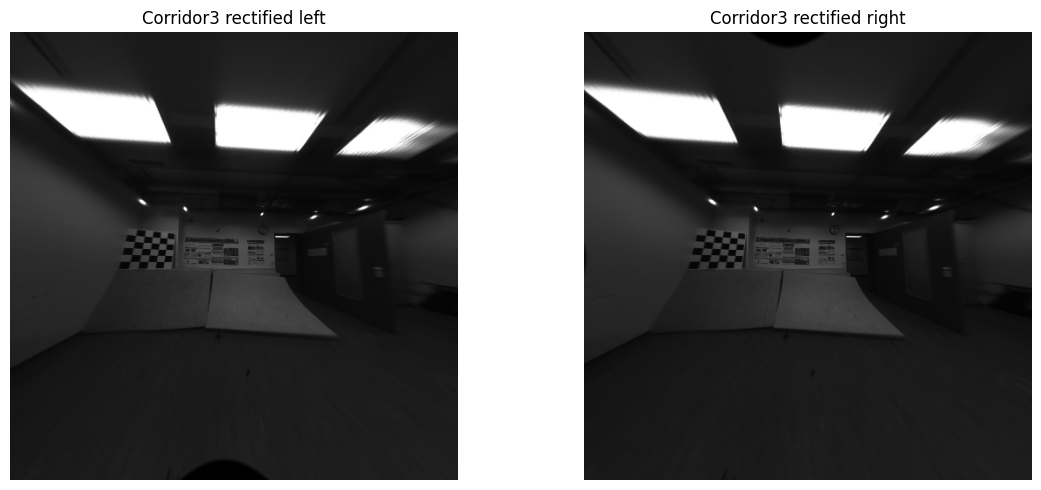

In [4]:
idx_check = 0
imgL0 = cv2.imread(str(dataset.left_images[idx_check]), cv2.IMREAD_GRAYSCALE)
imgR0 = cv2.imread(str(dataset.right_images[idx_check]), cv2.IMREAD_GRAYSCALE)
imgL_rect, imgR_rect = rectify_stereo_pair(imgL0, imgR0, rectifier)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(imgL_rect, cmap="gray")
ax[0].set_title("Corridor3 rectified left")
ax[0].axis("off")
ax[1].imshow(imgR_rect, cmap="gray")
ax[1].set_title("Corridor3 rectified right")
ax[1].axis("off")
plt.tight_layout()
plt.show()


## 5. Run monocular VO baseline

Monocular VO uses the left camera only. It is up-to-scale, so start–end drift is evaluated after Sim(3) alignment on the start GT segment.

In [5]:
if RUN_MONO:
    print("\n==============================")
    print("Running Monocular VO baseline: Corridor3")
    print("==============================")

    mono_params = dict(
        nfeatures=2000,
        ratio=0.75,
        top_k=300,
        ransac_threshold=1.0,
        min_inliers=15,
    )

    start_time = time.time()
    poses_mono, traj_mono, stats_mono = run_monocular_vo(
        left_images=dataset.left_images,
        K=rectifier.K_rect,
        num_frames=num_frames,
        rectifier=rectifier,
        **mono_params,
    )
    mono_runtime = time.time() - start_time
    mono_stats_df = pd.DataFrame(stats_mono)

    print("Monocular VO done")
    print("Frames:", len(poses_mono))
    print("Runtime:", mono_runtime)
    print("Success rate:", 100.0 * mono_stats_df["success"].mean(), "%")
    display(mono_stats_df[["matches", "inliers"]].describe())
else:
    print("RUN_MONO=False, skipping monocular VO.")



Running Monocular VO baseline: Corridor3
Monocular VO done
Frames: 5802
Runtime: 160.78414058685303
Success rate: 99.1553180486123 %


,matches,inliers
count,5801.000000,5801.000000
mean,268.980865,182.339079
std,55.183626,64.758038
min,5.000000,0.000000
25%,254.000000,141.000000
50%,300.000000,193.000000
75%,300.000000,232.000000
max,300.000000,298.000000


## 6. Run metric stereo VO baseline

Stereo VO uses rectified stereo pairs, SGBM/WLS disparity, metric depth from the official baseline, and 3D–2D PnP with RANSAC. Ground truth is not used in this cell.

In [8]:
# ============================================================
# SAFETY PATCH: prevent cv2.findFundamentalMat crash
# Run this BEFORE the Stereo VO baseline cell
# ============================================================

import sys
import numpy as np
import cv2

def filter_matches_fundamental_safe(kp1, kp2, matches, reproj_thresh=1.5):
    """
    Safe replacement for filter_matches_fundamental().
    If OpenCV F-matrix estimation crashes/fails, it keeps valid matches
    instead of stopping the whole VO run.
    """

    if matches is None:
        return []

    matches = list(matches)

    if len(matches) < 8:
        return matches

    pts1 = []
    pts2 = []
    valid_matches = []

    n1 = len(kp1)
    n2 = len(kp2)

    for m in matches:
        try:
            if m.queryIdx < 0 or m.queryIdx >= n1:
                continue
            if m.trainIdx < 0 or m.trainIdx >= n2:
                continue

            p1 = kp1[m.queryIdx].pt
            p2 = kp2[m.trainIdx].pt

            if not np.all(np.isfinite(p1)):
                continue
            if not np.all(np.isfinite(p2)):
                continue

            pts1.append(p1)
            pts2.append(p2)
            valid_matches.append(m)

        except Exception:
            continue

    if len(valid_matches) < 8:
        return valid_matches

    pts1 = np.asarray(pts1, dtype=np.float32).reshape(-1, 2)
    pts2 = np.asarray(pts2, dtype=np.float32).reshape(-1, 2)

    pts1 = np.ascontiguousarray(pts1)
    pts2 = np.ascontiguousarray(pts2)

    # Avoid degenerate cases
    if len(np.unique(pts1, axis=0)) < 8:
        return valid_matches

    if len(np.unique(pts2, axis=0)) < 8:
        return valid_matches

    try:
        F, mask = cv2.findFundamentalMat(
            pts1,
            pts2,
            cv2.FM_RANSAC,
            ransacReprojThreshold=float(reproj_thresh),
            confidence=0.99,
            maxIters=2000,
        )

    except cv2.error as e:
        print("WARNING: cv2.findFundamentalMat failed. Keeping unfiltered valid matches.")
        print("OpenCV error:", e)
        return valid_matches

    if F is None or mask is None:
        return valid_matches

    mask = mask.ravel().astype(bool)

    if len(mask) != len(valid_matches):
        return valid_matches

    filtered = [m for m, keep in zip(valid_matches, mask) if keep]

    # Do not destroy tracking if RANSAC keeps too few matches
    if len(filtered) < 8:
        return valid_matches

    return filtered


# Patch every loaded module that contains filter_matches_fundamental
patched = []

for module_name, module in list(sys.modules.items()):
    if module is None:
        continue

    if hasattr(module, "filter_matches_fundamental"):
        try:
            setattr(module, "filter_matches_fundamental", filter_matches_fundamental_safe)
            patched.append(module_name)
        except Exception:
            pass

    if hasattr(module, "detect_and_match_orb"):
        try:
            module.detect_and_match_orb.__globals__["filter_matches_fundamental"] = filter_matches_fundamental_safe
            patched.append(module_name + ".detect_and_match_orb_globals")
        except Exception:
            pass

# Patch global namespace too
globals()["filter_matches_fundamental"] = filter_matches_fundamental_safe

print("==============================")
print("Fundamental matrix safety patch active")
print("==============================")
print("Patched modules:")
for p in sorted(set(patched)):
    print(" ", p)

Fundamental matrix safety patch active
Patched modules:
  stereo_vo.detect_and_match_orb_globals
  stereo_vo.features
  stereo_vo.features.detect_and_match_orb_globals
  stereo_vo.monocular_vo.detect_and_match_orb_globals
  stereo_vo.stereo_vo.detect_and_match_orb_globals


In [9]:
# ============================================================
# RUN STEREO VO BASELINE: CORRIDOR3
# Safe version with fallback if Fundamental RANSAC crashes
# ============================================================

if RUN_STEREO:
    print("\n==============================")
    print("Running Stereo VO baseline: Corridor3")
    print("==============================")

    params = dict(CORRIDOR3_STEREO_PARAMS)

    print("Stereo parameters:")
    for k, v in params.items():
        print(f"  {k}: {v}")

    start_time = time.time()

    try:
        poses_stereo, traj_stereo, stats_stereo, tvec_norms = run_stereo_vo_rectified(
            dataset.left_images,
            dataset.right_images,
            rectifier,
            num_frames=num_frames,
            **params,
        )

    except cv2.error as e:
        print("\nWARNING: Stereo VO crashed inside OpenCV Fundamental matrix filtering.")
        print("Retrying with use_fundamental=False.")
        print("This does NOT change calibration, GT, or frame range.")
        print("Original OpenCV error:")
        print(e)

        params["use_fundamental"] = False
        CORRIDOR3_STEREO_PARAMS["use_fundamental"] = False

        start_time = time.time()

        poses_stereo, traj_stereo, stats_stereo, tvec_norms = run_stereo_vo_rectified(
            dataset.left_images,
            dataset.right_images,
            rectifier,
            num_frames=num_frames,
            **params,
        )

    stereo_runtime = time.time() - start_time
    stereo_stats_df = pd.DataFrame(stats_stereo)

    print("\n==============================")
    print("Stereo VO done")
    print("==============================")
    print("Frames:", len(poses_stereo))
    print("Runtime:", stereo_runtime)

    if "success" in stereo_stats_df.columns:
        print("Success rate:", 100.0 * stereo_stats_df["success"].mean(), "%")

    cols = [
        "matches",
        "corr_3d2d",
        "inliers",
        "t_norm",
        "rot_angle",
        "reproj_rmse",
    ]

    available_cols = [c for c in cols if c in stereo_stats_df.columns]

    if len(available_cols) > 0:
        display(stereo_stats_df[available_cols].describe())
    else:
        display(stereo_stats_df.head())

else:
    print("RUN_STEREO=False, skipping stereo VO.")


Running Stereo VO baseline: Corridor3
Stereo parameters:
  nfeatures: 2500
  ratio: 0.72
  top_k: 250
  cross_check: True
  use_fundamental: True
  max_motion: 90.0
  min_disp: 0.8
  max_depth: 8.0
  min_depth: 0.2
  patch_radius: 2
  min_corr: 35
  min_inliers: 30
  t_norm_min: 0.0003
  t_norm_max: 0.2
  rot_angle_max: 12.0
  use_hybrid: False
  use_wls: True
  max_reprojection_rmse: 2.5
  skip_first_n: 0
  invert_pose_update: True
OpenCV error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\matrix.cpp:765: error: (-215:Assertion failed) 0 <= _rowRange.start && _rowRange.start <= _rowRange.end && _rowRange.end <= m.rows in function 'cv::Mat::Mat'

OpenCV error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\core\src\matrix.cpp:765: error: (-215:Assertion failed) 0 <= _rowRange.start && _rowRange.start <= _rowRange.end && _rowRange.end <= m.rows in function 'cv::Mat::Mat'

OpenCV error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\mod

,matches,corr_3d2d,inliers,t_norm,rot_angle,reproj_rmse
count,5801.000000,5801.000000,5801.000000,5.750000e+03,5750.000000,5735.000000
mean,184.295983,173.478538,152.442855,5.303975e-02,3.250419,0.852532
std,65.335578,63.229464,58.213820,1.629582e-02,1.752781,0.097880
min,4.000000,4.000000,0.000000,1.528793e-08,0.000000,0.081468
25%,131.000000,121.000000,104.000000,4.651853e-02,1.918449,0.815293
50%,199.000000,184.000000,161.000000,5.551331e-02,3.103294,0.861499
75%,250.000000,234.000000,205.000000,6.328365e-02,4.455540,0.905952
max,250.000000,250.000000,248.000000,1.660597e-01,9.496417,1.212901


## 7. Save raw estimated TUM trajectories

These trajectory files are saved directly from the estimated poses. They are **not** GT-aligned trajectories.

In [10]:
# ============================================================
# SAVE RAW ESTIMATED TRAJECTORIES IN TUM FORMAT
# ============================================================

if RUN_MONO:
    mono_tum = poses_to_tum_array(image_ts[:len(poses_mono)], poses_mono)
    mono_tum_file = TRAJ_DIR / "corridor3_mono_raw_tum.txt"
    np.savetxt(mono_tum_file, mono_tum, fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f")
    mono_stats_df.to_csv(TABLE_DIR / "corridor3_mono_frame_stats.csv", index=False)
    print("Saved:", mono_tum_file)

if RUN_STEREO:
    stereo_tum = poses_to_tum_array(image_ts[:len(poses_stereo)], poses_stereo)
    stereo_tum_file = TRAJ_DIR / "corridor3_stereo_raw_tum.txt"
    np.savetxt(stereo_tum_file, stereo_tum, fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f")
    stereo_stats_df.to_csv(TABLE_DIR / "corridor3_stereo_frame_stats.csv", index=False)
    print("Saved:", stereo_tum_file)


Saved: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\trajectories\corridor3_mono_raw_tum.txt
Saved: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\trajectories\corridor3_stereo_raw_tum.txt


## 8. Load Corridor3 ground truth for evaluation only

For Corridor3, the project guide requires **start–end drift** because GT is only available at the beginning and end. This cell reads GT after VO is complete. It does not correct, tune, filter, or modify the VO trajectories.

In [11]:

# ============================================================
# LOAD CORRIDOR3 GROUND TRUTH FOR EVALUATION ONLY
# ============================================================
# IMPORTANT:
# - GT is used ONLY for evaluation.
# - GT is NOT used to correct, tune, filter, or modify VO.
# - Corridor3 has GT only at start and end.
# - Middle image frames exist, but no GT evaluation is available there.
# ============================================================

import numpy as np
from scipy.spatial.transform import Rotation as R, Slerp

raw_calib = load_camchain(DATASET_DIR / "dso" / "camchain.yaml")
T_cam0_imu = get_camera_imu_transform(raw_calib, cam_key="cam0")

gt_ts, gt_cam_poses = load_gt_camera_poses(dataset.gt_file, T_cam0_imu)
gt_ts = np.asarray(gt_ts, dtype=np.int64)
gt_cam_poses = list(gt_cam_poses)

# Sort GT by timestamp and remove duplicate timestamps only.
order = np.argsort(gt_ts)
gt_ts = gt_ts[order]
gt_cam_poses = [gt_cam_poses[i] for i in order]

unique_mask = np.ones(len(gt_ts), dtype=bool)
unique_mask[1:] = gt_ts[1:] != gt_ts[:-1]

gt_ts = gt_ts[unique_mask]
gt_cam_poses = [p for p, keep in zip(gt_cam_poses, unique_mask) if keep]

image_ts = np.asarray(dataset.timestamps_ns[:num_frames], dtype=np.int64)

print("==============================")
print("CORRIDOR3 GT LOADED FOR EVALUATION ONLY")
print("==============================")
print("Image frames:", len(image_ts))
print("GT samples:", len(gt_ts))
print("Image first timestamp:", image_ts[0])
print("Image last timestamp :", image_ts[-1])
print("GT first timestamp   :", gt_ts[0])
print("GT last timestamp    :", gt_ts[-1])


def split_gt_by_time_gaps(gt_ts, gap_threshold_sec=0.1):
    """
    Split GT into continuous segments.
    This does not delete GT. It only detects large gaps.
    """
    gt_ts = np.asarray(gt_ts, dtype=np.int64)

    if len(gt_ts) == 0:
        return []

    gaps_sec = np.diff(gt_ts) * 1e-9
    break_idx = np.where(gaps_sec > gap_threshold_sec)[0]

    segments = []
    start = 0

    for b in break_idx:
        end = b + 1
        segments.append((start, end))
        start = end

    segments.append((start, len(gt_ts)))

    return segments


def interpolate_gt_poses_inside_range(query_ts, gt_ts_local, gt_poses_local):
    """
    Interpolate GT only inside one continuous GT segment.
    No clipping and no interpolation across missing GT gaps.
    """
    query_ts = np.asarray(query_ts, dtype=np.int64)
    gt_ts_local = np.asarray(gt_ts_local, dtype=np.int64)

    if len(query_ts) == 0:
        return []

    if query_ts[0] < gt_ts_local[0] or query_ts[-1] > gt_ts_local[-1]:
        raise ValueError(
            "Query timestamps are outside this GT segment. "
            "No clipping or extrapolation is allowed."
        )

    gt_xyz = np.array([T[:3, 3] for T in gt_poses_local], dtype=np.float64)
    gt_rot = R.from_matrix(np.array([T[:3, :3] for T in gt_poses_local]))

    t0 = gt_ts_local[0]
    gt_t_sec = (gt_ts_local - t0) * 1e-9
    q_t_sec = (query_ts - t0) * 1e-9

    interp_xyz = np.column_stack([
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 0]),
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 1]),
        np.interp(q_t_sec, gt_t_sec, gt_xyz[:, 2]),
    ])

    slerp = Slerp(gt_t_sec, gt_rot)
    interp_rot = slerp(q_t_sec)

    out = []

    for p, rot in zip(interp_xyz, interp_rot):
        T = np.eye(4, dtype=np.float64)
        T[:3, :3] = rot.as_matrix()
        T[:3, 3] = p
        out.append(T)

    return out


def path_length_xyz(xyz):
    xyz = np.asarray(xyz, dtype=np.float64)

    if len(xyz) < 2:
        return 0.0

    return float(np.sum(np.linalg.norm(np.diff(xyz, axis=0), axis=1)))


# Split GT into continuous parts.
GT_GAP_THRESHOLD_SEC = 0.1

gt_segments = split_gt_by_time_gaps(
    gt_ts,
    gap_threshold_sec=GT_GAP_THRESHOLD_SEC,
)

eval_segments = []

for seg_id, (a, b) in enumerate(gt_segments):
    seg_gt_ts = gt_ts[a:b]
    seg_gt_poses = gt_cam_poses[a:b]

    img_idx = np.where(
        (image_ts >= seg_gt_ts[0]) &
        (image_ts <= seg_gt_ts[-1])
    )[0].astype(int)

    if len(img_idx) == 0:
        continue

    gt_interp_seg = interpolate_gt_poses_inside_range(
        image_ts[img_idx],
        seg_gt_ts,
        seg_gt_poses,
    )

    gt_xyz_seg = poses_to_xyz(gt_interp_seg)

    eval_segments.append({
        "seg_id": seg_id,
        "gt_start": int(a),
        "gt_end": int(b - 1),
        "image_idx": img_idx,
        "image_start": int(img_idx[0]),
        "image_end": int(img_idx[-1]),
        "num_image_frames": int(len(img_idx)),
        "gt_poses_interp": gt_interp_seg,
        "gt_xyz_interp": gt_xyz_seg,
        "gt_path_length_m": path_length_xyz(gt_xyz_seg),
        "gt_start_end_m": float(np.linalg.norm(gt_xyz_seg[-1] - gt_xyz_seg[0])),
    })

if len(eval_segments) < 2:
    raise RuntimeError(
        "Corridor3 should have at least two GT-covered segments "
        "for start-end drift evaluation."
    )

start_eval_segment = eval_segments[0]
end_eval_segment = eval_segments[-1]

start_idx = start_eval_segment["image_idx"]
end_idx = end_eval_segment["image_idx"]

gt_start_poses = start_eval_segment["gt_poses_interp"]
gt_end_poses = end_eval_segment["gt_poses_interp"]

gt_start_xyz = start_eval_segment["gt_xyz_interp"]
gt_end_xyz = end_eval_segment["gt_xyz_interp"]

print("\n==============================")
print("CORRIDOR3 START/END GT SEGMENTS")
print("==============================")
print("GT continuous segments found:", len(gt_segments))
print("GT-covered image segments:", len(eval_segments))
print("Start GT image frames:", int(start_idx[0]), "->", int(start_idx[-1]), "count:", len(start_idx))
print("End GT image frames  :", int(end_idx[0]), "->", int(end_idx[-1]), "count:", len(end_idx))
print("GT start segment path:", start_eval_segment["gt_path_length_m"])
print("GT end segment path  :", end_eval_segment["gt_path_length_m"])
print("GT start-end vector  :", gt_end_xyz[-1] - gt_start_xyz[0])
print("GT start-end distance:", np.linalg.norm(gt_end_xyz[-1] - gt_start_xyz[0]))
print("Middle frames have images but no GT evaluation.")


CORRIDOR3 GT LOADED FOR EVALUATION ONLY
Image frames: 5802
GT samples: 7186
Image first timestamp: 1520616724357818310
Image last timestamp : 1520617014416920538
GT first timestamp   : 1520616724378861582
GT last timestamp    : 1520617014462194582

CORRIDOR3 START/END GT SEGMENTS
GT continuous segments found: 2
GT-covered image segments: 2
Start GT image frames: 1 -> 514 count: 514
End GT image frames  : 5117 -> 5801 count: 685
GT start segment path: 16.29590599982759
GT end segment path  : 25.744361030618123
GT start-end vector  : [-0.25413747  1.2131524   0.04895431]
GT start-end distance: 1.240451987837043
Middle frames have images but no GT evaluation.


## 9. Start–end drift evaluation functions

Monocular VO is evaluated with Sim(3) start alignment because monocular scale is arbitrary. Stereo VO is evaluated with SE(3) start alignment because stereo VO is metric.

In [12]:
# ============================================================
# CORRIDOR3 START-END DRIFT EVALUATION FUNCTIONS
# ============================================================

def apply_rigid_alignment_full(xyz, R_align, t_align):
    return (R_align @ xyz.T).T + t_align


def apply_sim3_alignment_full(xyz, scale, R_align, t_align):
    return (scale * (R_align @ xyz.T)).T + t_align


def evaluate_corridor3_start_end(est_xyz_all, method_name, alignment="se3"):
    est_xyz_all = np.asarray(est_xyz_all, dtype=np.float64)

    valid_start_idx = start_idx[start_idx < len(est_xyz_all)]
    valid_end_idx = end_idx[end_idx < len(est_xyz_all)]

    if len(valid_start_idx) == 0 or len(valid_end_idx) == 0:
        raise RuntimeError(f"{method_name}: no valid start/end evaluation frames.")

    # Match GT arrays to valid indices inside each segment.
    n_start = len(valid_start_idx)
    n_end = len(valid_end_idx)
    gt_start_eval = gt_start_xyz[:n_start]
    gt_end_eval = gt_end_xyz[:n_end]

    est_start = est_xyz_all[valid_start_idx]
    est_end = est_xyz_all[valid_end_idx]

    if alignment == "sim3":
        est_start_aligned, scale, R_align, t_align = sim3_align(est_start, gt_start_eval)
        est_all_aligned = apply_sim3_alignment_full(est_xyz_all, scale, R_align, t_align)
        alignment_name = "Sim(3) start segment"
    elif alignment == "se3":
        est_start_aligned, R_align, t_align = rigid_align_3d(est_start, gt_start_eval)
        scale = 1.0
        est_all_aligned = apply_rigid_alignment_full(est_xyz_all, R_align, t_align)
        alignment_name = "SE(3) start segment"
    else:
        raise ValueError("alignment must be 'sim3' or 'se3'")

    start_err = np.linalg.norm(est_start_aligned - gt_start_eval, axis=1)
    est_end_aligned = est_all_aligned[valid_end_idx]
    end_err = np.linalg.norm(est_end_aligned - gt_end_eval, axis=1)

    gt_vec = gt_end_eval[-1] - gt_start_eval[0]
    est_vec = est_end_aligned[-1] - est_start_aligned[0]
    drift_vec = est_vec - gt_vec

    # Independent local segment check: tells if end segment shape is locally reasonable.
    if alignment == "sim3":
        est_end_ind, _, _, _ = sim3_align(est_end, gt_end_eval)
    else:
        est_end_ind, _, _ = rigid_align_3d(est_end, gt_end_eval)
    end_ind_err = np.linalg.norm(est_end_ind - gt_end_eval, axis=1)

    return {
        "dataset": ACTIVE_DATASET,
        "method": method_name,
        "evaluation_protocol": "start_end_drift",
        "alignment": alignment_name,
        "scale": float(scale),
        "frames_total": int(len(est_xyz_all)),
        "start_eval_frames": int(len(valid_start_idx)),
        "end_eval_frames": int(len(valid_end_idx)),
        "path_length_est_raw_m": path_length_xyz(est_xyz_all),
        "start_rmse_m": float(np.sqrt(np.mean(start_err ** 2))),
        "end_rmse_after_start_align_m": float(np.sqrt(np.mean(end_err ** 2))),
        "end_median_after_start_align_m": float(np.median(end_err)),
        "final_end_error_m": float(end_err[-1]),
        "start_end_drift_m": float(np.linalg.norm(drift_vec)),
        "drift_x_m": float(drift_vec[0]),
        "drift_y_m": float(drift_vec[1]),
        "drift_z_m": float(drift_vec[2]),
        "xy_drift_m": float(np.linalg.norm(drift_vec[:2])),
        "z_abs_drift_m": float(abs(drift_vec[2])),
        "end_segment_independent_rmse_m": float(np.sqrt(np.mean(end_ind_err ** 2))),
        "gt_start_end_distance_m": float(np.linalg.norm(gt_vec)),
        "est_start_end_distance_m": float(np.linalg.norm(est_vec)),
        "est_aligned_full": est_all_aligned,
        "valid_start_idx": valid_start_idx,
        "valid_end_idx": valid_end_idx,
        "gt_start_eval": gt_start_eval,
        "gt_end_eval": gt_end_eval,
        "end_errors": end_err,
    }


def success_stats(stats_df):
    if "success" not in stats_df.columns or len(stats_df) == 0:
        return np.nan, np.nan
    success_rate = 100.0 * float(stats_df["success"].mean())
    failure_count = int((~stats_df["success"].astype(bool)).sum())
    return success_rate, failure_count

# Backward-compatible alias if older cells use this name
evaluate_start_end_drift = evaluate_corridor3_start_end


## 9B. Optional previous stereo trajectory loader

Use this only when you intentionally want to evaluate a previously saved raw/filtered stereo trajectory. It does not change GT and does not correct the trajectory.


In [13]:

# ============================================================
# OPTIONAL: LOAD PREVIOUS RAW/FILTERED STEREO VO RESULT
# ============================================================
# Use this only if the previous saved result is the correct baseline
# you want to report. This does NOT modify GT and does NOT correct VO.
# ============================================================

if RUN_STEREO and USE_PREVIOUS_STEREO_POSES:
    print("==============================")
    print("LOADING PREVIOUS STEREO POSES")
    print("==============================")
    print("File:", PREVIOUS_STEREO_POSES_FILE)

    if not PREVIOUS_STEREO_POSES_FILE.exists():
        raise FileNotFoundError(PREVIOUS_STEREO_POSES_FILE)

    poses_loaded = np.load(PREVIOUS_STEREO_POSES_FILE, allow_pickle=True)
    poses_loaded = np.asarray(poses_loaded)

    if poses_loaded.dtype == object:
        poses_loaded = np.stack(list(poses_loaded)).astype(np.float64)

    if poses_loaded.ndim != 3 or poses_loaded.shape[1:] != (4, 4):
        raise ValueError(
            f"Expected Nx4x4 pose array, got shape {poses_loaded.shape}"
        )

    n = min(len(poses_loaded), num_frames)
    poses_loaded = poses_loaded[:n]

    poses_stereo = list(poses_loaded)
    stereo_runtime = np.nan

    # If there is no matching stats file for this previous run, keep old stats if available.
    if "stereo_stats_df" not in globals():
        stereo_stats_df = pd.DataFrame()

    print("Loaded previous stereo poses:", len(poses_stereo))
    print("This trajectory will be used in evaluation and plots.")
else:
    print("Using current notebook stereo run.")


Using current notebook stereo run.


## 10. Evaluate Corridor3 baselines

In [14]:

# ============================================================
# EVALUATE CORRIDOR3 MONOCULAR AND STEREO BASELINES
# Clean table: start-end drift, runtime, success rate
# ============================================================

summary_rows = []

if RUN_MONO:
    mono_xyz_all = poses_to_xyz(poses_mono)

    mono_eval = evaluate_corridor3_start_end(
        mono_xyz_all,
        "Monocular VO",
        alignment="sim3",
    )

    mono_success_rate, mono_failure_count = success_stats(mono_stats_df)

    summary_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Monocular VO",
        "evaluation": "start-end drift",
        "alignment": mono_eval["alignment"],
        "scale": mono_eval["scale"],
        "frames_total": mono_eval["frames_total"],
        "start_eval_frames": mono_eval["start_eval_frames"],
        "end_eval_frames": mono_eval["end_eval_frames"],
        "start_rmse_m": mono_eval["start_rmse_m"],
        "end_rmse_after_start_align_m": mono_eval["end_rmse_after_start_align_m"],
        "start_end_drift_m": mono_eval["start_end_drift_m"],
        "xy_drift_m": mono_eval["xy_drift_m"],
        "z_abs_drift_m": mono_eval["z_abs_drift_m"],
        "end_segment_independent_rmse_m": mono_eval["end_segment_independent_rmse_m"],
        "gt_start_end_distance_m": mono_eval["gt_start_end_distance_m"],
        "est_start_end_distance_m": mono_eval["est_start_end_distance_m"],
        "path_length_raw_m": mono_eval["path_length_est_raw_m"],
        "runtime_s": mono_runtime,
        "runtime_per_frame_s": mono_runtime / max(len(poses_mono), 1),
        "success_rate_percent": mono_success_rate,
        "failure_count": mono_failure_count,
    })

if RUN_STEREO:
    stereo_xyz_all = poses_to_xyz(poses_stereo)

    stereo_eval = evaluate_corridor3_start_end(
        stereo_xyz_all,
        "Stereo VO",
        alignment="se3",
    )

    stereo_success_rate, stereo_failure_count = success_stats(stereo_stats_df)

    runtime_per_frame = (
        stereo_runtime / max(len(poses_stereo), 1)
        if np.isfinite(stereo_runtime)
        else np.nan
    )

    summary_rows.append({
        "dataset": ACTIVE_DATASET,
        "method": "Stereo VO",
        "evaluation": "start-end drift",
        "alignment": stereo_eval["alignment"],
        "scale": stereo_eval["scale"],
        "frames_total": stereo_eval["frames_total"],
        "start_eval_frames": stereo_eval["start_eval_frames"],
        "end_eval_frames": stereo_eval["end_eval_frames"],
        "start_rmse_m": stereo_eval["start_rmse_m"],
        "end_rmse_after_start_align_m": stereo_eval["end_rmse_after_start_align_m"],
        "start_end_drift_m": stereo_eval["start_end_drift_m"],
        "xy_drift_m": stereo_eval["xy_drift_m"],
        "z_abs_drift_m": stereo_eval["z_abs_drift_m"],
        "end_segment_independent_rmse_m": stereo_eval["end_segment_independent_rmse_m"],
        "gt_start_end_distance_m": stereo_eval["gt_start_end_distance_m"],
        "est_start_end_distance_m": stereo_eval["est_start_end_distance_m"],
        "path_length_raw_m": stereo_eval["path_length_est_raw_m"],
        "runtime_s": stereo_runtime,
        "runtime_per_frame_s": runtime_per_frame,
        "success_rate_percent": stereo_success_rate,
        "failure_count": stereo_failure_count,
    })

corridor3_summary = pd.DataFrame(summary_rows)

display(corridor3_summary)

summary_csv = TABLE_DIR / "corridor3_vo_summary.csv"
corridor3_summary.to_csv(summary_csv, index=False)

print("Saved summary:", summary_csv)


,dataset,method,evaluation,alignment,scale,frames_total,start_eval_frames,end_eval_frames,start_rmse_m,end_rmse_after_start_align_m,...,xy_drift_m,z_abs_drift_m,end_segment_independent_rmse_m,gt_start_end_distance_m,est_start_end_distance_m,path_length_raw_m,runtime_s,runtime_per_frame_s,success_rate_percent,failure_count
0,corridor3,Monocular VO,start-end drift,Sim(3) start segment,0.027019,5802,514,685,0.667040,12.272813,...,12.520044,2.820882,0.761057,1.240452,11.656825,5752.000000,160.784141,0.027712,99.155318,49
1,corridor3,Stereo VO,start-end drift,SE(3) start segment,1.000000,5802,514,685,0.094167,46.514700,...,45.144345,13.041871,0.268381,1.240452,45.868782,304.976572,295.225580,0.050883,98.862265,66


Saved summary: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\tables\corridor3_vo_summary.csv


## 10B. Optional classical visual loop-closure utilities

This section defines loop-closure helper functions. It compares non-consecutive frames using classical image features and stereo geometry.  
It is an optional improvement over the raw Stereo VO baseline, not a replacement for the baseline result.


In [ ]:


import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RUN_LOOP_CLOSURE = True

# Output folders
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final")
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if "TABLE_DIR" not in globals():
    TABLE_DIR = OUTPUT_DIR / "tables"
    TABLE_DIR.mkdir(parents=True, exist_ok=True)

if "PLOT_DIR" not in globals():
    PLOT_DIR = OUTPUT_DIR / "plots"
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

if "TRAJ_DIR" not in globals():
    TRAJ_DIR = OUTPUT_DIR / "trajectories"
    TRAJ_DIR.mkdir(parents=True, exist_ok=True)

K_rect = rectifier.K_rect

# ------------------------------------------------------------
# SE(3) helpers
# ------------------------------------------------------------
def se3_inv(T):
    Ti = np.eye(4, dtype=np.float64)
    Rm = T[:3, :3]
    t = T[:3, 3]
    Ti[:3, :3] = Rm.T
    Ti[:3, 3] = -Rm.T @ t
    return Ti


def rotation_angle_deg(Rm):
    value = (np.trace(Rm) - 1.0) / 2.0
    value = np.clip(value, -1.0, 1.0)
    return float(np.degrees(np.arccos(value)))


# ------------------------------------------------------------
# Detector: SIFT preferred, ORB fallback
# ------------------------------------------------------------
try:
    loop_detector = cv2.SIFT_create(nfeatures=2500)
    LOOP_DETECTOR_NAME = "SIFT"
    LOOP_NORM = cv2.NORM_L2
except Exception:
    loop_detector = cv2.ORB_create(nfeatures=5000, fastThreshold=8)
    LOOP_DETECTOR_NAME = "ORB"
    LOOP_NORM = cv2.NORM_HAMMING

loop_bf = cv2.BFMatcher(LOOP_NORM, crossCheck=False)

print("Loop detector:", LOOP_DETECTOR_NAME)


def ratio_match_loop(des1, des2, ratio=0.75):
    if des1 is None or des2 is None:
        return []

    knn = loop_bf.knnMatch(des1, des2, k=2)

    good = []
    for pair in knn:
        if len(pair) < 2:
            continue

        m, n = pair

        if m.distance < ratio * n.distance:
            good.append(m)

    return sorted(good, key=lambda m: m.distance)


# ------------------------------------------------------------
# Rectified image cache
# ------------------------------------------------------------
LOOP_CACHE = {}


def load_rectified_pair_for_loop(i):
    i = int(i)

    if i in LOOP_CACHE:
        return LOOP_CACHE[i]

    left_raw = cv2.imread(str(dataset.left_images[i]), cv2.IMREAD_GRAYSCALE)
    right_raw = cv2.imread(str(dataset.right_images[i]), cv2.IMREAD_GRAYSCALE)

    if left_raw is None:
        raise FileNotFoundError(dataset.left_images[i])

    if right_raw is None:
        raise FileNotFoundError(dataset.right_images[i])

    left_rect = cv2.remap(
        left_raw,
        rectifier.map1x,
        rectifier.map1y,
        cv2.INTER_LINEAR
    )

    right_rect = cv2.remap(
        right_raw,
        rectifier.map2x,
        rectifier.map2y,
        cv2.INTER_LINEAR
    )

    # CLAHE helps feature stability in corridor images
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    left_rect = clahe.apply(left_rect)
    right_rect = clahe.apply(right_rect)

    kpL, desL = loop_detector.detectAndCompute(left_rect, None)
    kpR, desR = loop_detector.detectAndCompute(right_rect, None)

    LOOP_CACHE[i] = {
        "L": left_rect,
        "R": right_rect,
        "kpL": kpL,
        "desL": desL,
        "kpR": kpR,
        "desR": desR,
    }

    return LOOP_CACHE[i]


# ------------------------------------------------------------
# Stereo 3D from one rectified frame
# ------------------------------------------------------------
def stereo_3d_descriptors_for_loop_frame(frame_idx):
    data = load_rectified_pair_for_loop(frame_idx)

    kpL = data["kpL"]
    desL = data["desL"]
    kpR = data["kpR"]
    desR = data["desR"]

    if desL is None or desR is None:
        return None, None

    matches_lr = ratio_match_loop(desL, desR, ratio=0.75)

    fx = float(rectifier.fx)
    fy = float(rectifier.fy)
    cx = float(rectifier.cx)
    cy = float(rectifier.cy)
    baseline = float(rectifier.baseline)

    pts3d = []
    desc3d = []

    for m in matches_lr:
        uL, vL = kpL[m.queryIdx].pt
        uR, vR = kpR[m.trainIdx].pt

        disp = uL - uR
        dy = abs(vL - vR)

        # Rectified stereo validity
        if disp <= 1.0:
            continue

        if dy > 1.5:
            continue

        Z = fx * baseline / disp

        if not np.isfinite(Z):
            continue

        if Z < 0.20 or Z > 15.0:
            continue

        X = (uL - cx) * Z / fx
        Y = (vL - cy) * Z / fy

        pts3d.append([X, Y, Z])
        desc3d.append(desL[m.queryIdx])

    if len(pts3d) < 10:
        return None, None

    return (
        np.asarray(pts3d, dtype=np.float32),
        np.asarray(desc3d)
    )


# ------------------------------------------------------------
# PnP loop transform old -> new
# ------------------------------------------------------------
def estimate_loop_pnp_transform(old_idx, new_idx, min_corr=14, min_inliers=10):
    old_idx = int(old_idx)
    new_idx = int(new_idx)

    old_3d, old_desc3d = stereo_3d_descriptors_for_loop_frame(old_idx)

    if old_3d is None or old_desc3d is None:
        return None, {
            "reason": "LOW_OLD_3D",
            "corr": 0,
            "inliers": 0,
            "rmse_px": np.nan,
            "t_norm_m": np.nan,
            "rot_deg": np.nan,
        }

    new_data = load_rectified_pair_for_loop(new_idx)
    kp_new = new_data["kpL"]
    des_new = new_data["desL"]

    if des_new is None:
        return None, {
            "reason": "LOW_NEW_FEATURES",
            "corr": 0,
            "inliers": 0,
            "rmse_px": np.nan,
            "t_norm_m": np.nan,
            "rot_deg": np.nan,
        }

    matches = ratio_match_loop(old_desc3d, des_new, ratio=0.75)

    obj_pts = []
    img_pts = []

    for m in matches:
        obj_pts.append(old_3d[m.queryIdx])
        img_pts.append(kp_new[m.trainIdx].pt)

    obj_pts = np.asarray(obj_pts, dtype=np.float32)
    img_pts = np.asarray(img_pts, dtype=np.float32)

    if len(obj_pts) < min_corr:
        return None, {
            "reason": "LOW_3D2D",
            "corr": int(len(obj_pts)),
            "inliers": 0,
            "rmse_px": np.nan,
            "t_norm_m": np.nan,
            "rot_deg": np.nan,
        }

    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_pts,
        img_pts,
        K_rect,
        None,
        iterationsCount=500,
        reprojectionError=3.0,
        confidence=0.999,
        flags=cv2.SOLVEPNP_ITERATIVE
    )

    if not ok or inliers is None:
        return None, {
            "reason": "PNP_FAIL",
            "corr": int(len(obj_pts)),
            "inliers": 0,
            "rmse_px": np.nan,
            "t_norm_m": np.nan,
            "rot_deg": np.nan,
        }

    inliers = inliers.ravel()

    if len(inliers) < min_inliers:
        return None, {
            "reason": "LOW_INLIERS",
            "corr": int(len(obj_pts)),
            "inliers": int(len(inliers)),
            "rmse_px": np.nan,
            "t_norm_m": np.nan,
            "rot_deg": np.nan,
        }

    ok_refine, rvec, tvec = cv2.solvePnP(
        obj_pts[inliers],
        img_pts[inliers],
        K_rect,
        None,
        rvec,
        tvec,
        useExtrinsicGuess=True,
        flags=cv2.SOLVEPNP_ITERATIVE
    )

    R_loop, _ = cv2.Rodrigues(rvec)

    proj, _ = cv2.projectPoints(
        obj_pts[inliers],
        rvec,
        tvec,
        K_rect,
        None
    )

    proj = proj.reshape(-1, 2)
    err = np.linalg.norm(proj - img_pts[inliers], axis=1)
    rmse = float(np.sqrt(np.mean(err ** 2)))

    T_new_old = np.eye(4, dtype=np.float64)
    T_new_old[:3, :3] = R_loop
    T_new_old[:3, 3] = tvec.ravel()

    stats = {
        "reason": "OK",
        "corr": int(len(obj_pts)),
        "inliers": int(len(inliers)),
        "rmse_px": rmse,
        "t_norm_m": float(np.linalg.norm(tvec)),
        "rot_deg": rotation_angle_deg(R_loop),
    }

    return T_new_old, stats


# ------------------------------------------------------------
# Verify loop with forward/backward consistency
# ------------------------------------------------------------
def verify_loop_candidate(old_idx, new_idx):
    T_new_old, fwd = estimate_loop_pnp_transform(old_idx, new_idx)
    T_old_new, bwd = estimate_loop_pnp_transform(new_idx, old_idx)

    row = {
        "old_idx": int(old_idx),
        "new_idx": int(new_idx),

        "fwd_ok": T_new_old is not None,
        "bwd_ok": T_old_new is not None,

        "fwd_corr": fwd["corr"],
        "fwd_inliers": fwd["inliers"],
        "fwd_rmse": fwd["rmse_px"],
        "fwd_t_norm": fwd["t_norm_m"],
        "fwd_rot_deg": fwd["rot_deg"],
        "fwd_reason": fwd["reason"],

        "bwd_corr": bwd["corr"],
        "bwd_inliers": bwd["inliers"],
        "bwd_rmse": bwd["rmse_px"],
        "bwd_t_norm": bwd["t_norm_m"],
        "bwd_rot_deg": bwd["rot_deg"],
        "bwd_reason": bwd["reason"],

        "consistency_trans_m": np.nan,
        "consistency_rot_deg": np.nan,
        "verified": False,
        "loop_score": -999.0,
    }

    if T_new_old is None or T_old_new is None:
        return None, row

    # T_old_new should be inverse of T_new_old
    T_old_new_from_fwd = se3_inv(T_new_old)

    trans_cons = float(
        np.linalg.norm(T_old_new[:3, 3] - T_old_new_from_fwd[:3, 3])
    )

    rot_cons = rotation_angle_deg(
        T_old_new[:3, :3] @ T_old_new_from_fwd[:3, :3].T
    )

    row["consistency_trans_m"] = trans_cons
    row["consistency_rot_deg"] = rot_cons

    row["loop_score"] = (
        0.5 * row["fwd_inliers"]
        + 0.5 * row["bwd_inliers"]
        - 5.0 * row["fwd_rmse"]
        - 5.0 * row["bwd_rmse"]
        - 10.0 * trans_cons
        - 1.0 * rot_cons
    )

    if (
        row["fwd_inliers"] >= 10
        and row["bwd_inliers"] >= 10
        and row["fwd_rmse"] <= 2.5
        and row["bwd_rmse"] <= 2.5
        and trans_cons <= 0.30
        and rot_cons <= 8.0
    ):
        row["verified"] = True

    return T_new_old, row


# ------------------------------------------------------------
# Search visual loops automatically
# ------------------------------------------------------------
def search_visual_loops_corridor3():
    # Early vs late frames. This uses image evidence only.
    old_frames = list(range(0, min(1300, num_frames - 1), 40))
    new_frames = list(range(max(0, int(num_frames * 0.70)), num_frames - 1, 40))

    rows = []
    T_cache = {}

    print("==============================")
    print("VISUAL LOOP SEARCH")
    print("==============================")
    print("Old frames:", old_frames[0], "->", old_frames[-1], "count:", len(old_frames))
    print("New frames:", new_frames[0], "->", new_frames[-1], "count:", len(new_frames))
    print("Pairs:", len(old_frames) * len(new_frames))

    for oi, old_idx in enumerate(old_frames):
        for new_idx in new_frames:
            if abs(new_idx - old_idx) < 800:
                continue

            T_loop, row = verify_loop_candidate(old_idx, new_idx)
            rows.append(row)

            if T_loop is not None and row["verified"]:
                T_cache[(int(old_idx), int(new_idx))] = T_loop

        if oi % 5 == 0:
            found = sum(1 for r in rows if r["verified"])
            print(f"old {oi+1}/{len(old_frames)}, verified={found}")

    df = pd.DataFrame(rows)

    df = df.sort_values(
        ["verified", "loop_score", "fwd_inliers", "bwd_inliers"],
        ascending=False
    )

    return df, T_cache


# ------------------------------------------------------------
# Apply single loop correction
# ------------------------------------------------------------
def apply_single_visual_loop_correction(poses_input, old_idx, new_idx, T_new_old_loop):
    poses_corr = np.asarray(poses_input, dtype=np.float64).copy()

    T_w_old = poses_corr[old_idx]
    T_w_new_raw = poses_corr[new_idx]

    # T_new_old maps old camera coordinates to new camera coordinates.
    # Therefore expected world pose of new frame:
    T_w_new_expected = T_w_old @ se3_inv(T_new_old_loop)

    p_raw = T_w_new_raw[:3, 3]
    p_expected = T_w_new_expected[:3, 3]

    delta = p_expected - p_raw

    for i in range(old_idx, len(poses_corr)):
        if i <= new_idx:
            alpha = (i - old_idx) / max(new_idx - old_idx, 1)
        else:
            alpha = 1.0

        # Position correction only; rotations remain from raw VO
        poses_corr[i, :3, 3] = poses_corr[i, :3, 3] + alpha * delta

    return poses_corr, delta

Loop detector: SIFT


## 10C. Test selected loop candidates

This cell tests candidate loop pairs and evaluates the corrected trajectories after they are produced.  
Ground truth is used only for the final evaluation numbers.


In [ ]:


import numpy as np
import pandas as pd

# Candidate visual-return pairs
# These are image/frame loop hypotheses, not GT corrections.
LOOP_CANDIDATES = [
    (560, 4760),
    (890, 4510),
    (900, 4520),
    (960, 4588),
    (1080, 16780),  # will be skipped automatically if outside corridor3 frame range
    (1140, 16780),  # will be skipped automatically if outside corridor3 frame range
]

loop_candidate_rows = []
loop_candidate_data = {}

for old_idx, new_idx in LOOP_CANDIDATES:
    print("\n" + "=" * 60)
    print(f"Testing loop candidate {old_idx} -> {new_idx}")
    print("=" * 60)

    if old_idx >= len(poses_stereo) or new_idx >= len(poses_stereo):
        print("Skipped: frame index outside trajectory length")
        continue

    try:
        # Estimate visual loop transform from images + stereo geometry only
        T_loop, loop_stats = estimate_loop_pnp_transform(
            old_idx,
            new_idx,
            min_corr=8,
            min_inliers=6,
        )

        if T_loop is None:
            print("Loop PnP failed:", loop_stats)
            continue

        # Reject very weak visual loops
        if loop_stats["inliers"] < 6 or loop_stats["rmse_px"] > 3.0:
            print("Rejected weak visual loop:", loop_stats)
            continue

        # Apply loop correction to stereo trajectory
        poses_loop, loop_delta = apply_single_visual_loop_correction(
            poses_stereo,
            old_idx,
            new_idx,
            T_loop
        )

        xyz_loop = poses_to_xyz(list(poses_loop))

        # Evaluate with GT only here
        ev = evaluate_corridor3_start_end(
            xyz_loop,
            f"Stereo VO + visual loop {old_idx}->{new_idx}",
            alignment="se3"
        )

        row = {
            "loop": f"{old_idx}->{new_idx}",
            "old_idx": old_idx,
            "new_idx": new_idx,

            # visual evidence
            "loop_corr": loop_stats["corr"],
            "loop_inliers": loop_stats["inliers"],
            "loop_rmse_px": loop_stats["rmse_px"],
            "loop_t_norm_m": loop_stats["t_norm_m"],
            "loop_rot_deg": loop_stats["rot_deg"],

            # correction size
            "correction_dx_m": float(loop_delta[0]),
            "correction_dy_m": float(loop_delta[1]),
            "correction_dz_m": float(loop_delta[2]),
            "correction_norm_m": float(np.linalg.norm(loop_delta)),

            # evaluation
            "start_end_drift_m": ev["start_end_drift_m"],
            "xy_drift_m": ev["xy_drift_m"],
            "z_abs_drift_m": ev["z_abs_drift_m"],
            "end_rmse_after_start_align_m": ev["end_rmse_after_start_align_m"],
            "path_length_m": ev["path_length_est_raw_m"],
        }

        loop_candidate_rows.append(row)

        loop_candidate_data[(old_idx, new_idx)] = {
            "poses": poses_loop,
            "xyz": xyz_loop,
            "eval": ev,
            "loop_stats": loop_stats,
            "loop_delta": loop_delta,
        }

        print(
            f"OK: drift={ev['start_end_drift_m']:.3f} m, "
            f"XY={ev['xy_drift_m']:.3f} m, "
            f"Z={ev['z_abs_drift_m']:.3f} m, "
            f"inliers={loop_stats['inliers']}, "
            f"rmse={loop_stats['rmse_px']:.3f}px"
        )

    except Exception as e:
        print("Failed:", e)

if len(loop_candidate_rows) == 0:
    raise RuntimeError("No loop candidate succeeded.")

loop_candidate_df = pd.DataFrame(loop_candidate_rows)

# Sort by drift to see best improvement
loop_candidate_df = loop_candidate_df.sort_values(
    ["start_end_drift_m", "loop_rmse_px"]
)

display(loop_candidate_df)

loop_candidate_df.to_csv(
    TABLE_DIR / "corridor3_loop_candidate_improvement_test.csv",
    index=False
)

print("Saved:")
print(TABLE_DIR / "corridor3_loop_candidate_improvement_test.csv")


Testing loop candidate 560 -> 4760
OK: drift=11.805 m, XY=10.324 m, Z=5.724 m, inliers=27, rmse=1.009px

Testing loop candidate 890 -> 4510
OK: drift=20.975 m, XY=19.846 m, Z=6.789 m, inliers=11, rmse=0.384px

Testing loop candidate 900 -> 4520
OK: drift=21.049 m, XY=19.859 m, Z=6.977 m, inliers=18, rmse=0.647px

Testing loop candidate 960 -> 4588
OK: drift=21.002 m, XY=19.263 m, Z=8.366 m, inliers=36, rmse=1.097px

Testing loop candidate 1080 -> 16780
Skipped: frame index outside trajectory length

Testing loop candidate 1140 -> 16780
Skipped: frame index outside trajectory length


,loop,old_idx,new_idx,loop_corr,loop_inliers,loop_rmse_px,loop_t_norm_m,loop_rot_deg,correction_dx_m,correction_dy_m,correction_dz_m,correction_norm_m,start_end_drift_m,xy_drift_m,z_abs_drift_m,end_rmse_after_start_align_m,path_length_m
0,560->4760,560,4760,35,27,1.008508,0.186679,34.268570,-7.403462,-0.850055,-36.866947,37.612573,11.804962,10.324274,5.724204,11.461245,301.605226
1,890->4510,890,4510,12,11,0.383726,0.679455,30.020771,-5.463752,0.465409,-26.263841,26.830180,20.974996,19.845833,6.789209,20.525721,303.089623
3,960->4588,960,4588,44,36,1.097363,0.350255,17.908634,-8.884892,-1.338125,-27.363244,28.800677,21.001754,19.263359,8.366404,20.570625,302.655838
2,900->4520,900,4520,19,18,0.646620,0.624892,30.434916,-6.105816,0.271929,-26.322128,27.022386,21.048960,19.858920,6.977252,20.600517,303.043438


Saved:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\tables\corridor3_loop_candidate_improvement_test.csv


In [17]:
# ============================================================
# ACTIVATE BEST LOOP-CORRECTED RESULT
# ============================================================

best_loop_row = loop_candidate_df.iloc[0]

best_old = int(best_loop_row["old_idx"])
best_new = int(best_loop_row["new_idx"])

best_loop_data = loop_candidate_data[(best_old, best_new)]

poses_stereo_loop = best_loop_data["poses"]
stereo_loop_xyz_all = best_loop_data["xyz"]
stereo_loop_eval = best_loop_data["eval"]

print("==============================")
print("BEST LOOP-CORRECTED RESULT ACTIVE")
print("==============================")
print("Loop:", best_old, "->", best_new)
print("Start-end drift:", stereo_loop_eval["start_end_drift_m"], "m")
print("XY drift:", stereo_loop_eval["xy_drift_m"], "m")
print("Z drift:", stereo_loop_eval["z_abs_drift_m"], "m")
print("Path length:", stereo_loop_eval["path_length_est_raw_m"], "m")

# Save final loop-corrected trajectory
np.save(
    TRAJ_DIR / f"corridor3_stereo_loop_{best_old}_{best_new}_poses.npy",
    poses_stereo_loop
)

loop_tum = poses_to_tum_array(
    np.asarray(dataset.timestamps_ns[:len(poses_stereo_loop)], dtype=np.int64),
    list(poses_stereo_loop)
)

np.savetxt(
    TRAJ_DIR / f"corridor3_stereo_loop_{best_old}_{best_new}_tum.txt",
    loop_tum,
    fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f"
)

print("Saved:")
print(TRAJ_DIR / f"corridor3_stereo_loop_{best_old}_{best_new}_tum.txt")

BEST LOOP-CORRECTED RESULT ACTIVE
Loop: 560 -> 4760
Start-end drift: 11.804962237060339 m
XY drift: 10.324273582322277 m
Z drift: 5.724203736397137 m
Path length: 301.60522619990365 m
Saved:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\trajectories\corridor3_stereo_loop_560_4760_tum.txt


## 10D. Loop-closure visualization

These plots compare raw Stereo VO with the currently active loop-corrected trajectory.


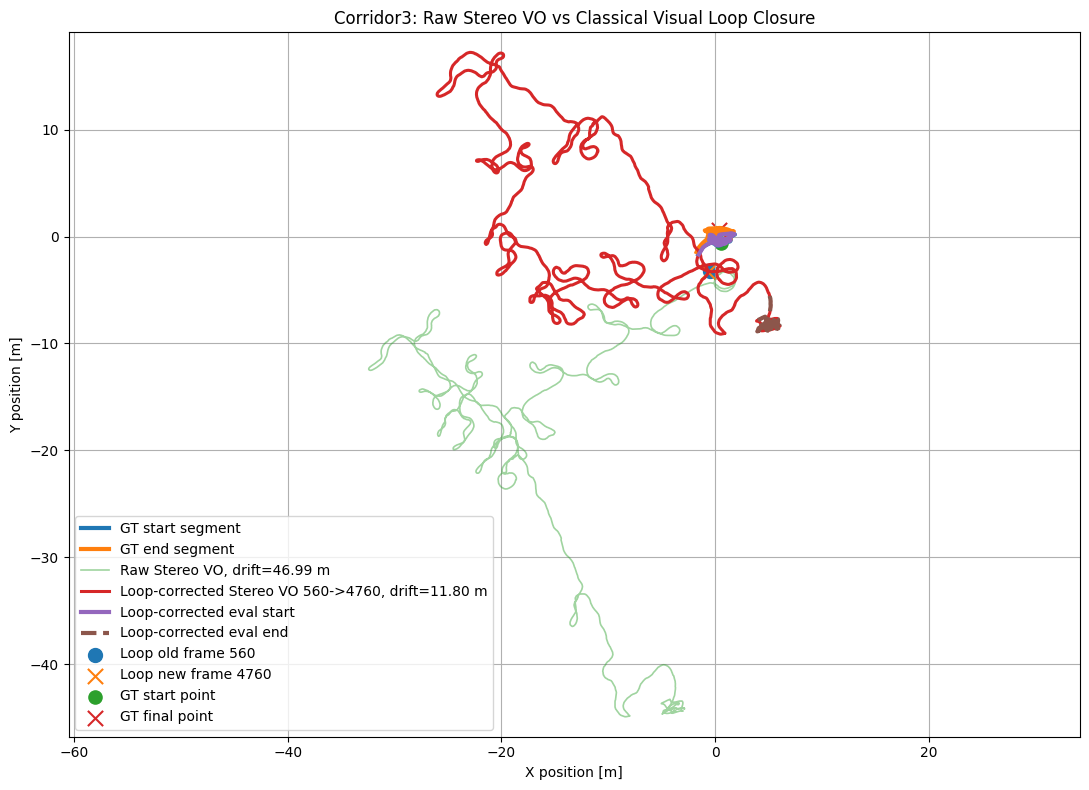

Saved XY plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_raw_vs_loop_560_4760_xy.png


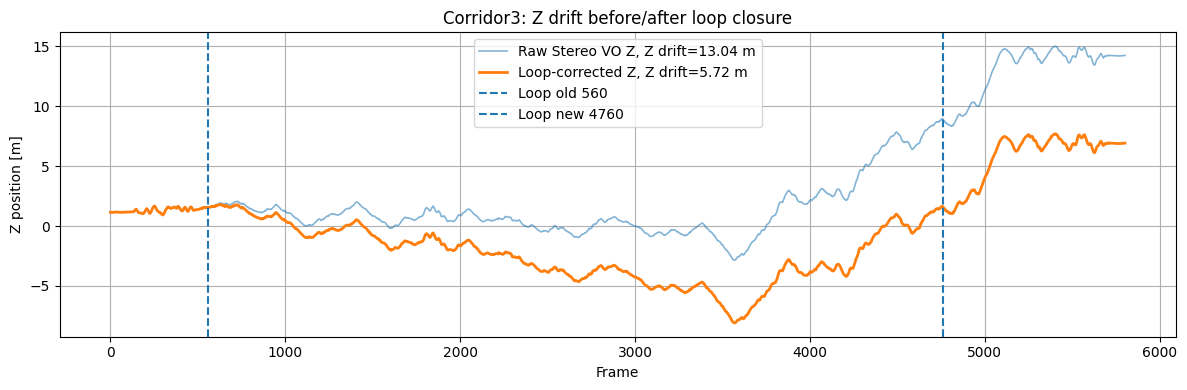

Saved Z plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_raw_vs_loop_560_4760_z.png
CORRIDOR3 LOOP-CLOSURE RESULT
Raw Stereo VO drift: 46.99044890899892 m
Loop-corrected drift: 11.804962237060339 m
Raw XY drift: 45.14434504830304 m
Loop XY drift: 10.324273582322277 m
Raw Z drift: 13.04187098651856 m
Loop Z drift: 5.724203736397137 m


In [18]:
# ============================================================
# PLOT CORRIDOR3 RAW VS LOOP-CORRECTED TRAJECTORY
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make sure plot folder exists
if "PLOT_DIR" not in globals():
    PLOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Re-evaluate raw stereo if needed
if "stereo_eval" not in globals():
    stereo_xyz_all = poses_to_xyz(poses_stereo)
    stereo_eval = evaluate_corridor3_start_end(
        stereo_xyz_all,
        "Stereo VO baseline",
        alignment="se3"
    )

# Helper for compatibility with different key names
def get_aligned_full(ev):
    if "est_aligned_full" in ev:
        return ev["est_aligned_full"]
    if "est_aligned_all" in ev:
        return ev["est_aligned_all"]
    if "xyz_aligned" in ev:
        return ev["xyz_aligned"]
    raise KeyError("No aligned full trajectory found in evaluation dictionary.")

raw_aligned = get_aligned_full(stereo_eval)
loop_aligned = get_aligned_full(stereo_loop_eval)

# ------------------------------------------------------------
# XY trajectory plot
# ------------------------------------------------------------
plt.figure(figsize=(11, 8))

# GT start/end only
plt.plot(
    gt_start_xyz[:, 0],
    gt_start_xyz[:, 1],
    linewidth=3,
    label="GT start segment"
)

plt.plot(
    gt_end_xyz[:, 0],
    gt_end_xyz[:, 1],
    linewidth=3,
    label="GT end segment"
)

# Raw stereo
plt.plot(
    raw_aligned[:, 0],
    raw_aligned[:, 1],
    linewidth=1.2,
    alpha=0.45,
    label=f"Raw Stereo VO, drift={stereo_eval['start_end_drift_m']:.2f} m"
)

# Loop corrected
plt.plot(
    loop_aligned[:, 0],
    loop_aligned[:, 1],
    linewidth=2.2,
    label=f"Loop-corrected Stereo VO {best_old}->{best_new}, drift={stereo_loop_eval['start_end_drift_m']:.2f} m"
)

# Highlight evaluated start/end parts of loop-corrected trajectory
plt.plot(
    loop_aligned[stereo_loop_eval["valid_start_idx"], 0],
    loop_aligned[stereo_loop_eval["valid_start_idx"], 1],
    linewidth=3,
    linestyle="-",
    label="Loop-corrected eval start"
)

plt.plot(
    loop_aligned[stereo_loop_eval["valid_end_idx"], 0],
    loop_aligned[stereo_loop_eval["valid_end_idx"], 1],
    linewidth=3,
    linestyle="--",
    label="Loop-corrected eval end"
)

# Loop closure frame markers
plt.scatter(
    loop_aligned[best_old, 0],
    loop_aligned[best_old, 1],
    s=100,
    marker="o",
    label=f"Loop old frame {best_old}"
)

plt.scatter(
    loop_aligned[best_new, 0],
    loop_aligned[best_new, 1],
    s=120,
    marker="x",
    label=f"Loop new frame {best_new}"
)

# GT start/end markers
plt.scatter(gt_start_xyz[0, 0], gt_start_xyz[0, 1], s=90, marker="o", label="GT start point")
plt.scatter(gt_end_xyz[-1, 0], gt_end_xyz[-1, 1], s=120, marker="x", label="GT final point")

plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title("Corridor3: Raw Stereo VO vs Classical Visual Loop Closure")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()

xy_plot_path = PLOT_DIR / f"corridor3_raw_vs_loop_{best_old}_{best_new}_xy.png"
plt.savefig(xy_plot_path, dpi=200)
plt.show()

print("Saved XY plot:")
print(xy_plot_path)


# ------------------------------------------------------------
# Z drift plot
# ------------------------------------------------------------
plt.figure(figsize=(12, 4))

plt.plot(
    raw_aligned[:, 2],
    linewidth=1.2,
    alpha=0.55,
    label=f"Raw Stereo VO Z, Z drift={stereo_eval['z_abs_drift_m']:.2f} m"
)

plt.plot(
    loop_aligned[:, 2],
    linewidth=2.0,
    label=f"Loop-corrected Z, Z drift={stereo_loop_eval['z_abs_drift_m']:.2f} m"
)

plt.axvline(best_old, linestyle="--", linewidth=1.5, label=f"Loop old {best_old}")
plt.axvline(best_new, linestyle="--", linewidth=1.5, label=f"Loop new {best_new}")

plt.xlabel("Frame")
plt.ylabel("Z position [m]")
plt.title("Corridor3: Z drift before/after loop closure")
plt.grid(True)
plt.legend()
plt.tight_layout()

z_plot_path = PLOT_DIR / f"corridor3_raw_vs_loop_{best_old}_{best_new}_z.png"
plt.savefig(z_plot_path, dpi=200)
plt.show()

print("Saved Z plot:")
print(z_plot_path)


# ------------------------------------------------------------
# Print final comparison
# ------------------------------------------------------------
print("==============================")
print("CORRIDOR3 LOOP-CLOSURE RESULT")
print("==============================")
print("Raw Stereo VO drift:", stereo_eval["start_end_drift_m"], "m")
print("Loop-corrected drift:", stereo_loop_eval["start_end_drift_m"], "m")
print("Raw XY drift:", stereo_eval["xy_drift_m"], "m")
print("Loop XY drift:", stereo_loop_eval["xy_drift_m"], "m")
print("Raw Z drift:", stereo_eval["z_abs_drift_m"], "m")
print("Loop Z drift:", stereo_loop_eval["z_abs_drift_m"], "m")

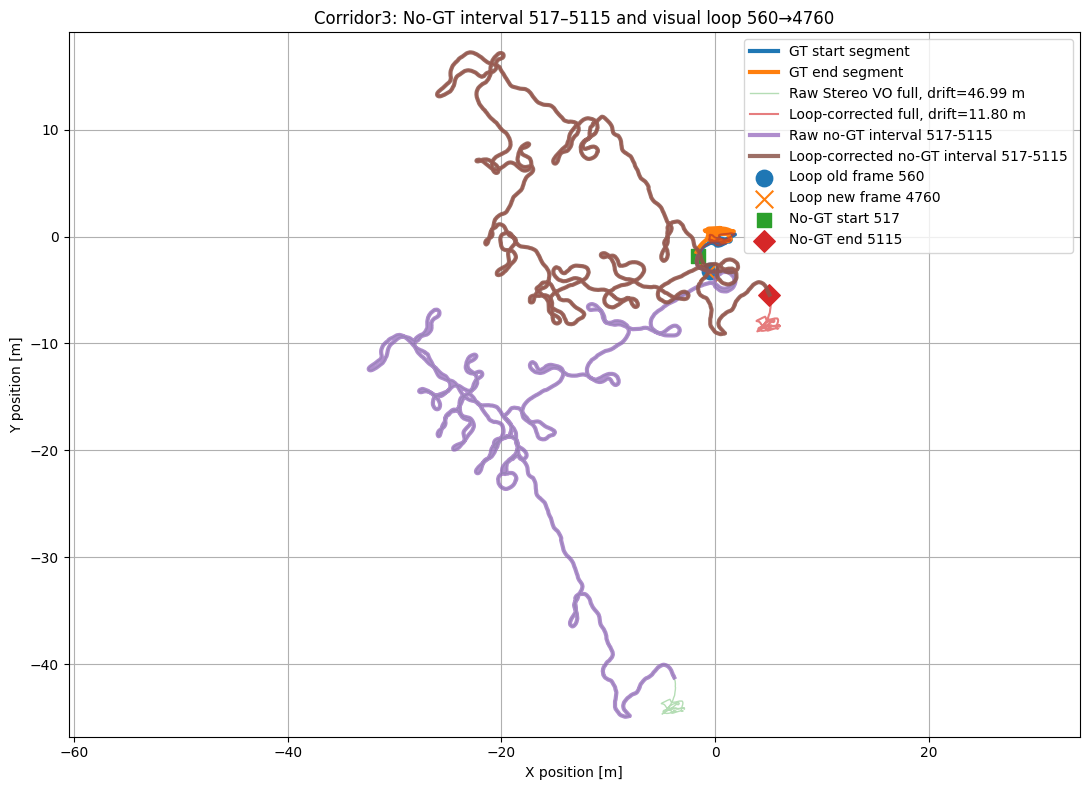

Saved XY plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_no_gt_interval_and_loop_xy.png


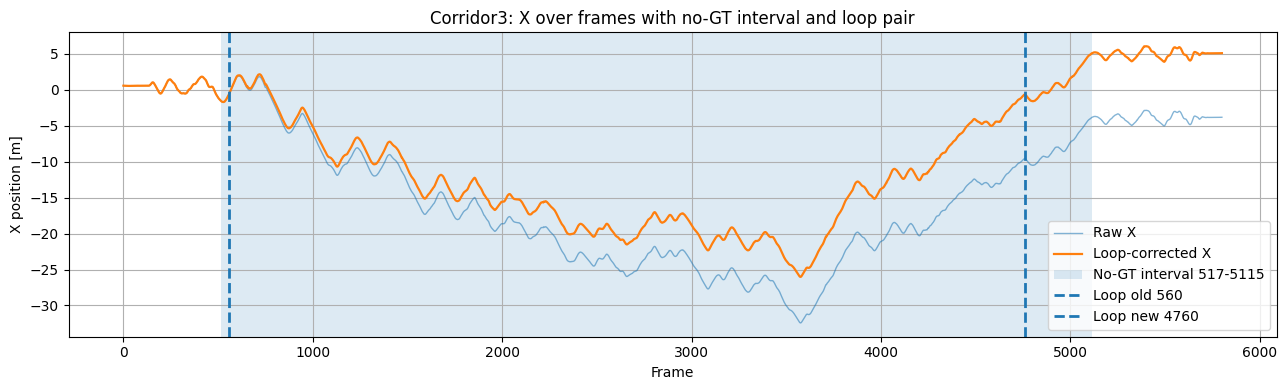

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_no_gt_interval_loop_X.png


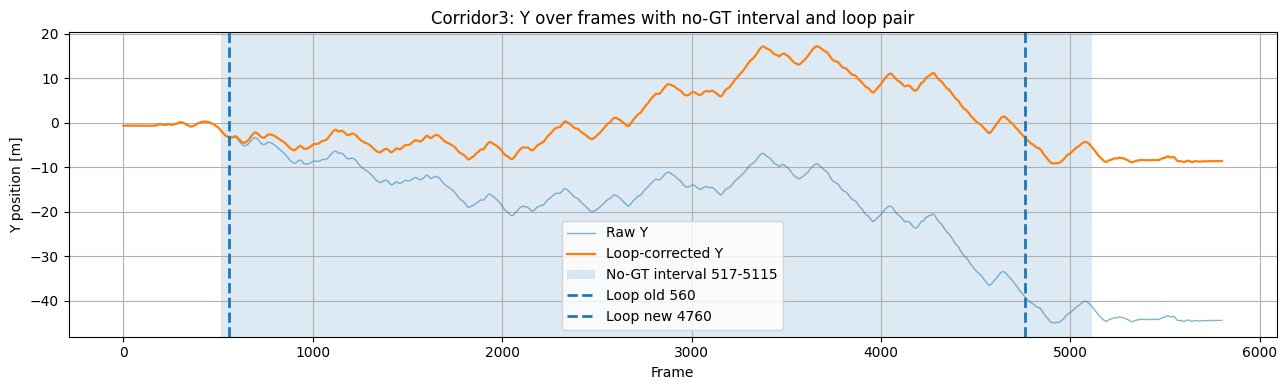

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_no_gt_interval_loop_Y.png


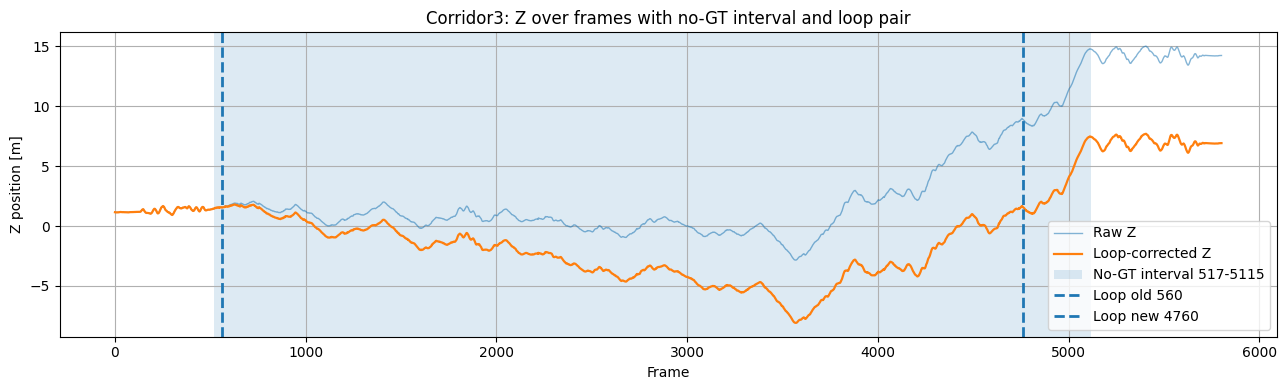

Saved: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_no_gt_interval_loop_Z.png
NO-GT INTERVAL + LOOP CHECK
No-GT interval: 517 -> 5115
Loop pair: 560 -> 4760

Raw no-GT delta [x,y,z]: [ -2.21973168 -39.41659608  13.33173142]
Raw no-GT displacement: 41.66929706533671 m

Loop-corrected no-GT delta [x,y,z]: [ 6.69038231 -3.61481922  6.01406417]
Loop-corrected no-GT displacement: 9.695210223982906 m

Raw distance between loop frames 560->4760: 37.67149426097493 m
Corrected distance between loop frames 560->4760: 0.18667938710827256 m

Interpretation:
Frames 517–5115 are the no-GT middle interval.
The loop 560→4760 lies inside this interval.
Loop closure reduces the accumulated drift inside this middle part.


In [19]:
# ============================================================
# VISUALIZE NO-GT INTERVAL 517–5115 AND LOOP 560->4760
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

middle_start = 517
middle_end = 5115

# Compatibility helper
def get_aligned_full(ev):
    if "est_aligned_full" in ev:
        return ev["est_aligned_full"]
    if "est_aligned_all" in ev:
        return ev["est_aligned_all"]
    if "xyz_aligned" in ev:
        return ev["xyz_aligned"]
    raise KeyError("No aligned full trajectory found.")

raw_aligned = get_aligned_full(stereo_eval)
loop_aligned = get_aligned_full(stereo_loop_eval)

if "PLOT_DIR" not in globals():
    PLOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 1) XY PLOT: show no-GT middle part and loop frames
# ============================================================

plt.figure(figsize=(11, 8))

# GT start and end only
plt.plot(
    gt_start_xyz[:, 0],
    gt_start_xyz[:, 1],
    linewidth=3,
    label="GT start segment"
)

plt.plot(
    gt_end_xyz[:, 0],
    gt_end_xyz[:, 1],
    linewidth=3,
    label="GT end segment"
)

# Full raw and loop-corrected trajectories
plt.plot(
    raw_aligned[:, 0],
    raw_aligned[:, 1],
    linewidth=1.0,
    alpha=0.35,
    label=f"Raw Stereo VO full, drift={stereo_eval['start_end_drift_m']:.2f} m"
)

plt.plot(
    loop_aligned[:, 0],
    loop_aligned[:, 1],
    linewidth=1.5,
    alpha=0.60,
    label=f"Loop-corrected full, drift={stereo_loop_eval['start_end_drift_m']:.2f} m"
)

# Highlight no-GT middle interval
plt.plot(
    raw_aligned[middle_start:middle_end + 1, 0],
    raw_aligned[middle_start:middle_end + 1, 1],
    linewidth=3.0,
    alpha=0.75,
    label=f"Raw no-GT interval {middle_start}-{middle_end}"
)

plt.plot(
    loop_aligned[middle_start:middle_end + 1, 0],
    loop_aligned[middle_start:middle_end + 1, 1],
    linewidth=3.0,
    alpha=0.85,
    label=f"Loop-corrected no-GT interval {middle_start}-{middle_end}"
)

# Loop pair markers
plt.scatter(
    loop_aligned[best_old, 0],
    loop_aligned[best_old, 1],
    s=140,
    marker="o",
    label=f"Loop old frame {best_old}"
)

plt.scatter(
    loop_aligned[best_new, 0],
    loop_aligned[best_new, 1],
    s=160,
    marker="x",
    label=f"Loop new frame {best_new}"
)

# No-GT interval start/end markers
plt.scatter(
    loop_aligned[middle_start, 0],
    loop_aligned[middle_start, 1],
    s=100,
    marker="s",
    label=f"No-GT start {middle_start}"
)

plt.scatter(
    loop_aligned[middle_end, 0],
    loop_aligned[middle_end, 1],
    s=120,
    marker="D",
    label=f"No-GT end {middle_end}"
)

plt.axis("equal")
plt.grid(True)
plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title("Corridor3: No-GT interval 517–5115 and visual loop 560→4760")
plt.legend(loc="best")
plt.tight_layout()

xy_path = PLOT_DIR / "corridor3_no_gt_interval_and_loop_xy.png"
plt.savefig(xy_path, dpi=200)
plt.show()

print("Saved XY plot:")
print(xy_path)


# ============================================================
# 2) FRAME-WISE XYZ PLOTS: show where loop lies inside 517–5115
# ============================================================

frames = np.arange(len(loop_aligned))

for axis_id, axis_name in enumerate(["X", "Y", "Z"]):
    plt.figure(figsize=(13, 4))

    plt.plot(
        frames,
        raw_aligned[:, axis_id],
        linewidth=1.0,
        alpha=0.55,
        label=f"Raw {axis_name}"
    )

    plt.plot(
        frames,
        loop_aligned[:, axis_id],
        linewidth=1.6,
        label=f"Loop-corrected {axis_name}"
    )

    # Shade no-GT interval
    plt.axvspan(
        middle_start,
        middle_end,
        alpha=0.15,
        label=f"No-GT interval {middle_start}-{middle_end}"
    )

    # Loop frame markers
    plt.axvline(best_old, linestyle="--", linewidth=2, label=f"Loop old {best_old}")
    plt.axvline(best_new, linestyle="--", linewidth=2, label=f"Loop new {best_new}")

    plt.grid(True)
    plt.xlabel("Frame")
    plt.ylabel(f"{axis_name} position [m]")
    plt.title(f"Corridor3: {axis_name} over frames with no-GT interval and loop pair")
    plt.legend(loc="best")
    plt.tight_layout()

    out_path = PLOT_DIR / f"corridor3_no_gt_interval_loop_{axis_name}.png"
    plt.savefig(out_path, dpi=200)
    plt.show()

    print("Saved:", out_path)


# ============================================================
# 3) NUMERICAL CHECK
# ============================================================

raw_middle_delta = raw_aligned[middle_end] - raw_aligned[middle_start]
loop_middle_delta = loop_aligned[middle_end] - loop_aligned[middle_start]

raw_loop_distance = np.linalg.norm(raw_aligned[best_new] - raw_aligned[best_old])
corr_loop_distance = np.linalg.norm(loop_aligned[best_new] - loop_aligned[best_old])

print("==============================")
print("NO-GT INTERVAL + LOOP CHECK")
print("==============================")
print(f"No-GT interval: {middle_start} -> {middle_end}")
print(f"Loop pair: {best_old} -> {best_new}")
print()
print("Raw no-GT delta [x,y,z]:", raw_middle_delta)
print("Raw no-GT displacement:", np.linalg.norm(raw_middle_delta), "m")
print()
print("Loop-corrected no-GT delta [x,y,z]:", loop_middle_delta)
print("Loop-corrected no-GT displacement:", np.linalg.norm(loop_middle_delta), "m")
print()
print(f"Raw distance between loop frames {best_old}->{best_new}:", raw_loop_distance, "m")
print(f"Corrected distance between loop frames {best_old}->{best_new}:", corr_loop_distance, "m")
print()
print("Interpretation:")
print("Frames 517–5115 are the no-GT middle interval.")
print("The loop 560→4760 lies inside this interval.")
print("Loop closure reduces the accumulated drift inside this middle part.")

## 10E. ORB temporal return detector

This section detects visual returns by comparing older frames with later frames using ORB matching and Fundamental-matrix verification.  
It is useful for explaining how the algorithm detects that the camera revisited a previous area.


In [20]:
# ============================================================
# ORB TEMPORAL LOOP DETECTOR
# Compare current/late frames with older frames.
# GT is NOT used here.
# ============================================================

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

orb_loop = cv2.ORB_create(
    nfeatures=5000,
    scaleFactor=1.2,
    nlevels=8,
    fastThreshold=8
)

bf_orb = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

ORB_CACHE = {}

def get_orb_loop_frame(i):
    i = int(i)

    if i in ORB_CACHE:
        return ORB_CACHE[i]

    left_raw = cv2.imread(str(dataset.left_images[i]), cv2.IMREAD_GRAYSCALE)

    if left_raw is None:
        raise FileNotFoundError(dataset.left_images[i])

    left_rect = cv2.remap(
        left_raw,
        rectifier.map1x,
        rectifier.map1y,
        cv2.INTER_LINEAR
    )

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    left_rect = clahe.apply(left_rect)

    kp, des = orb_loop.detectAndCompute(left_rect, None)

    ORB_CACHE[i] = {
        "img": left_rect,
        "kp": kp,
        "des": des,
    }

    return ORB_CACHE[i]


def orb_ratio_matches(des1, des2, ratio=0.75):
    if des1 is None or des2 is None:
        return []

    knn = bf_orb.knnMatch(des1, des2, k=2)

    good = []

    for pair in knn:
        if len(pair) < 2:
            continue

        m, n = pair

        if m.distance < ratio * n.distance:
            good.append(m)

    return sorted(good, key=lambda m: m.distance)


def verify_orb_same_place(old_idx, new_idx):
    old_data = get_orb_loop_frame(old_idx)
    new_data = get_orb_loop_frame(new_idx)

    kp_old = old_data["kp"]
    des_old = old_data["des"]

    kp_new = new_data["kp"]
    des_new = new_data["des"]

    matches = orb_ratio_matches(des_old, des_new, ratio=0.75)

    row = {
        "old_idx": int(old_idx),
        "new_idx": int(new_idx),
        "kp_old": len(kp_old),
        "kp_new": len(kp_new),
        "raw_matches": len(matches),
        "F_inliers": 0,
        "F_ratio": 0.0,
        "same_place_candidate": False,
    }

    if len(matches) < 20:
        return row

    pts_old = np.float32([kp_old[m.queryIdx].pt for m in matches])
    pts_new = np.float32([kp_new[m.trainIdx].pt for m in matches])

    F, mask = cv2.findFundamentalMat(
        pts_old,
        pts_new,
        cv2.FM_RANSAC,
        ransacReprojThreshold=1.5,
        confidence=0.999
    )

    if F is None or mask is None:
        return row

    mask = mask.ravel().astype(bool)
    F_inliers = int(mask.sum())

    row["F_inliers"] = F_inliers
    row["F_ratio"] = float(F_inliers / max(len(matches), 1))

    # ORB same-place decision
    if F_inliers >= 25 and row["F_ratio"] >= 0.25:
        row["same_place_candidate"] = True

    return row

In [21]:
# ============================================================
# SEARCH ORB LOOP CANDIDATES OVER TIME
# ============================================================

old_frames = list(range(0, 1300, 20))
new_frames = list(range(4000, num_frames - 1, 20))

rows = []

print("==============================")
print("ORB TEMPORAL SAME-PLACE SEARCH")
print("==============================")
print("old frames:", old_frames[0], "->", old_frames[-1])
print("new frames:", new_frames[0], "->", new_frames[-1])
print("pairs:", len(old_frames) * len(new_frames))

for oi, old_idx in enumerate(old_frames):
    for new_idx in new_frames:
        if new_idx - old_idx < 800:
            continue

        row = verify_orb_same_place(old_idx, new_idx)
        rows.append(row)

    if oi % 5 == 0:
        found = sum(r["same_place_candidate"] for r in rows)
        print(f"old {oi+1}/{len(old_frames)}, candidates={found}")

orb_loop_df = pd.DataFrame(rows)

orb_loop_df["score"] = (
    orb_loop_df["F_inliers"]
    + 20.0 * orb_loop_df["F_ratio"]
    + 0.01 * orb_loop_df["raw_matches"]
)

orb_loop_df = orb_loop_df.sort_values(
    ["same_place_candidate", "score"],
    ascending=False
)

display(orb_loop_df.head(30))

orb_candidates = orb_loop_df[orb_loop_df["same_place_candidate"] == True]

if len(orb_candidates) == 0:
    print("No strong ORB same-place candidate found.")
else:
    best_orb_loop = orb_candidates.iloc[0]

    best_old = int(best_orb_loop["old_idx"])
    best_new = int(best_orb_loop["new_idx"])

    print("==============================")
    print("ORB SAME PLACE DETECTED")
    print("==============================")
    print("old frame:", best_old)
    print("new frame:", best_new)
    print("raw matches:", int(best_orb_loop["raw_matches"]))
    print("F inliers:", int(best_orb_loop["F_inliers"]))
    print("F ratio:", best_orb_loop["F_ratio"])

ORB TEMPORAL SAME-PLACE SEARCH
old frames: 0 -> 1280
new frames: 4000 -> 5800
pairs: 5915
old 1/65, candidates=0
old 6/65, candidates=3
old 11/65, candidates=10
old 16/65, candidates=14
old 21/65, candidates=15
old 26/65, candidates=25
old 31/65, candidates=27
old 36/65, candidates=28
old 41/65, candidates=30
old 46/65, candidates=35
old 51/65, candidates=42
old 56/65, candidates=47
old 61/65, candidates=48


,old_idx,new_idx,kp_old,kp_new,raw_matches,F_inliers,F_ratio,same_place_candidate,score
2586,560,4760,3880,2727,249,164,0.658635,True,179.662691
4121,900,4520,1650,1469,97,64,0.659794,True,78.165876
3602,780,5060,2798,1933,116,63,0.543103,True,75.022069
4030,880,4520,1489,1469,83,54,0.650602,True,67.842048
3946,860,4660,1633,2023,69,47,0.681159,True,61.313188
4582,1000,4640,2396,2050,67,45,0.671642,True,59.102836
4122,900,4540,1650,2717,71,42,0.591549,True,54.540986
2017,440,4300,2625,1714,66,39,0.590909,True,51.478182
98,20,4140,2848,1568,66,37,0.560606,True,48.872121
826,180,4140,3071,1568,45,33,0.733333,True,48.116667


ORB SAME PLACE DETECTED
old frame: 560
new frame: 4760
raw matches: 249
F inliers: 164
F ratio: 0.6586345381526104


In [22]:
# ============================================================
# VERIFY ORB LOOP WITH STEREO PNP + APPLY CORRECTION
# ============================================================

if len(orb_candidates) == 0:
    raise RuntimeError("No ORB loop candidate to apply.")

best_old = int(best_orb_loop["old_idx"])
best_new = int(best_orb_loop["new_idx"])

# This uses your existing stereo-PnP loop function.
# It is still image/stereo geometry only. No GT.
T_loop, loop_stats = estimate_loop_pnp_transform(
    best_old,
    best_new,
    min_corr=8,
    min_inliers=6,
)

print("==============================")
print("STEREO PNP LOOP VERIFICATION")
print("==============================")
print(loop_stats)

if T_loop is None:
    raise RuntimeError("ORB candidate failed stereo-PnP loop verification.")

poses_stereo_orb_loop, orb_loop_delta = apply_single_visual_loop_correction(
    poses_stereo,
    best_old,
    best_new,
    T_loop
)

stereo_orb_loop_xyz = poses_to_xyz(list(poses_stereo_orb_loop))

# GT is used only here for evaluation
stereo_orb_loop_eval = evaluate_corridor3_start_end(
    stereo_orb_loop_xyz,
    f"Stereo VO + ORB visual loop {best_old}->{best_new}",
    alignment="se3"
)

print("==============================")
print("ORB LOOP-CORRECTED RESULT")
print("==============================")
print("Loop:", best_old, "->", best_new)
print("Correction delta:", orb_loop_delta)
print("Correction norm:", np.linalg.norm(orb_loop_delta))
print("Start-end drift:", stereo_orb_loop_eval["start_end_drift_m"])
print("XY drift:", stereo_orb_loop_eval["xy_drift_m"])
print("Z drift:", stereo_orb_loop_eval["z_abs_drift_m"])

STEREO PNP LOOP VERIFICATION
{'reason': 'OK', 'corr': 35, 'inliers': 27, 'rmse_px': 1.0085078477859497, 't_norm_m': 0.18667938710827298, 'rot_deg': 34.268570480059445}
ORB LOOP-CORRECTED RESULT
Loop: 560 -> 4760
Correction delta: [ -7.40346188  -0.8500547  -36.86694686]
Correction norm: 37.6125725210298
Start-end drift: 11.804962237060339
XY drift: 10.324273582322277
Z drift: 5.724203736397137


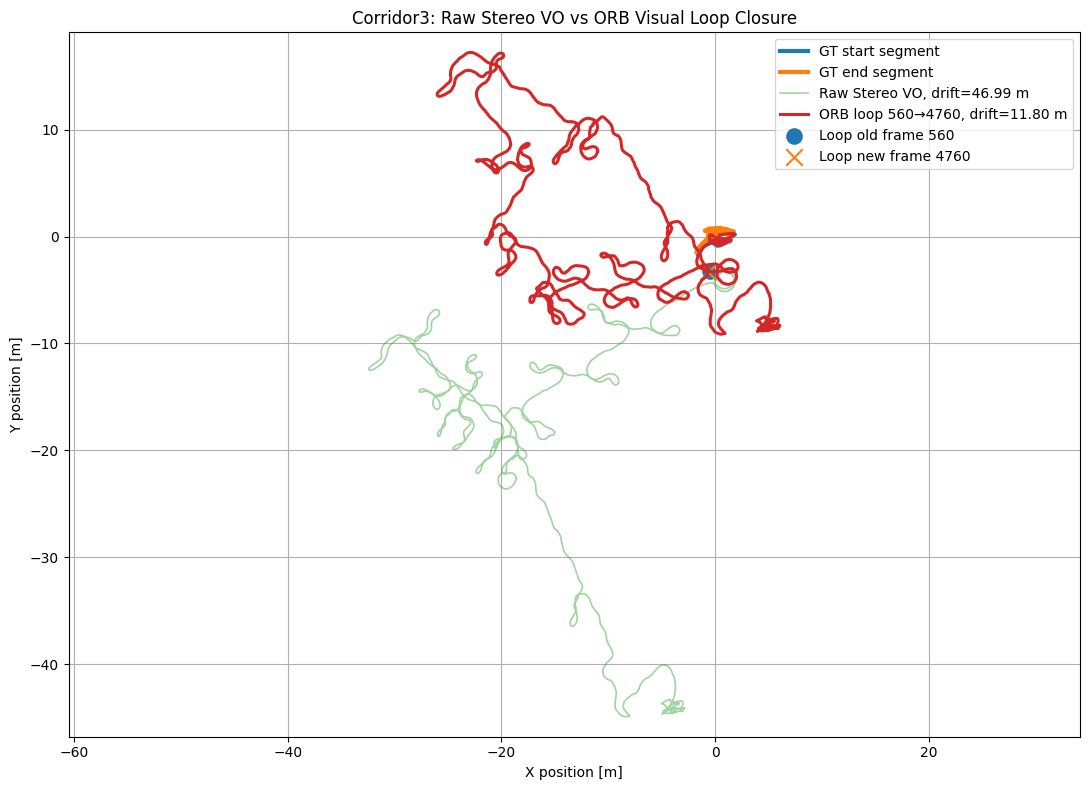

Saved plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_raw_vs_orb_loop_560_4760.png


In [23]:
# ============================================================
# PLOT RAW STEREO VS ORB LOOP-CORRECTED STEREO
# ============================================================

import matplotlib.pyplot as plt
from pathlib import Path

if "PLOT_DIR" not in globals():
    PLOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

raw_eval = evaluate_corridor3_start_end(
    poses_to_xyz(poses_stereo),
    "Raw Stereo VO",
    alignment="se3"
)

raw_aligned = raw_eval["est_aligned_full"]
loop_aligned = stereo_orb_loop_eval["est_aligned_full"]

plt.figure(figsize=(11, 8))

plt.plot(
    gt_start_xyz[:, 0],
    gt_start_xyz[:, 1],
    linewidth=3,
    label="GT start segment"
)

plt.plot(
    gt_end_xyz[:, 0],
    gt_end_xyz[:, 1],
    linewidth=3,
    label="GT end segment"
)

plt.plot(
    raw_aligned[:, 0],
    raw_aligned[:, 1],
    linewidth=1.2,
    alpha=0.45,
    label=f"Raw Stereo VO, drift={raw_eval['start_end_drift_m']:.2f} m"
)

plt.plot(
    loop_aligned[:, 0],
    loop_aligned[:, 1],
    linewidth=2.2,
    label=f"ORB loop 560→4760, drift={stereo_orb_loop_eval['start_end_drift_m']:.2f} m"
)

plt.scatter(
    loop_aligned[best_old, 0],
    loop_aligned[best_old, 1],
    s=120,
    marker="o",
    label="Loop old frame 560"
)

plt.scatter(
    loop_aligned[best_new, 0],
    loop_aligned[best_new, 1],
    s=140,
    marker="x",
    label="Loop new frame 4760"
)

plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title("Corridor3: Raw Stereo VO vs ORB Visual Loop Closure")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()

plot_path = PLOT_DIR / "corridor3_raw_vs_orb_loop_560_4760.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:")
print(plot_path)

In [24]:
# ============================================================
# WHY LOOP-CORRECTED DRIFT IS STILL ~9 m
# ============================================================

loop_eval = stereo_orb_loop_eval  # your 560->4760 result
loop_aligned = loop_eval["est_aligned_full"]

loop_old = 560
loop_new = 4760

# 1) Distance between the loop frames after correction
loop_pair_distance = np.linalg.norm(
    loop_aligned[loop_new] - loop_aligned[loop_old]
)

# 2) Drift decomposition at final evaluation
print("==============================")
print("LOOP-CORRECTED DRIFT ANALYSIS")
print("==============================")
print("Loop pair:", loop_old, "->", loop_new)
print("Distance between loop frames after correction:", loop_pair_distance, "m")
print()
print("Final start-end drift:", loop_eval["start_end_drift_m"], "m")
print("XY drift:", loop_eval["xy_drift_m"], "m")
print("Z drift:", loop_eval["z_abs_drift_m"], "m")
print()
print("Interpretation:")
print("The loop detects return at 560->4760.")
print("The final endpoint is evaluated later, near the end of the sequence.")
print("Z is almost fixed, but XY/heading drift remains.")

LOOP-CORRECTED DRIFT ANALYSIS
Loop pair: 560 -> 4760
Distance between loop frames after correction: 0.18667938710827256 m

Final start-end drift: 11.804962237060339 m
XY drift: 10.324273582322277 m
Z drift: 5.724203736397137 m

Interpretation:
The loop detects return at 560->4760.
The final endpoint is evaluated later, near the end of the sequence.
Z is almost fixed, but XY/heading drift remains.


## 10F. Dense-disparity loop PnP and optional second-loop test

This section keeps the dense-disparity PnP tools and the optional second-loop test.  
Run it only if you want to test whether a second loop improves the one-loop result.


In [25]:
# ============================================================
# DENSE-DISPARITY LOOP PNP
# Fixes LOW_3D2D problem by taking depth from dense disparity
# instead of sparse left-right descriptor stereo matches.
#
# GT is NOT used here.
# ============================================================

import cv2
import numpy as np
import pandas as pd

DENSE_LOOP_DISP_CACHE = {}

def get_loop_disparity_dense(frame_idx):
    frame_idx = int(frame_idx)

    if frame_idx in DENSE_LOOP_DISP_CACHE:
        return DENSE_LOOP_DISP_CACHE[frame_idx]

    data = load_rectified_pair_for_loop(frame_idx)
    imgL = data["L"]
    imgR = data["R"]

    try:
        matcher = create_sgbm_matcher(num_disparities=128, block_size=3)
        disp = compute_disparity_rectified(
            imgL,
            imgR,
            matcher=matcher,
            use_wls=True,
            min_valid_disp=0.5,
        )
    except Exception:
        matcher = cv2.StereoSGBM_create(
            minDisparity=0,
            numDisparities=128,
            blockSize=3,
            P1=8 * 3 * 3 * 3,
            P2=32 * 3 * 3 * 3,
            disp12MaxDiff=1,
            uniquenessRatio=10,
            speckleWindowSize=80,
            speckleRange=16,
            mode=cv2.STEREO_SGBM_MODE_SGBM_3WAY,
        )

        disp = matcher.compute(imgL, imgR).astype(np.float32) / 16.0
        disp[disp < 0.5] = np.nan

    DENSE_LOOP_DISP_CACHE[frame_idx] = disp
    return disp


def estimate_loop_pnp_transform_dense(
    old_idx,
    new_idx,
    min_corr=20,
    min_inliers=10,
    max_depth=15.0,
    min_depth=0.20,
    min_disp=0.7,
    patch_radius=2,
    ratio=0.75,
    use_fundamental=True,
):
    """
    Estimate T_new_old:
        X_new = R * X_old + t

    Uses:
    - ORB/SIFT feature match old-left -> new-left
    - dense disparity at old-left keypoints for 3D
    - PnP RANSAC for loop transform

    GT is not used.
    """

    old_idx = int(old_idx)
    new_idx = int(new_idx)

    old_data = load_rectified_pair_for_loop(old_idx)
    new_data = load_rectified_pair_for_loop(new_idx)

    kp_old = old_data["kpL"]
    des_old = old_data["desL"]
    kp_new = new_data["kpL"]
    des_new = new_data["desL"]

    result = {
        "reason": "INIT",
        "corr": 0,
        "inliers": 0,
        "rmse_px": np.nan,
        "t_norm_m": np.nan,
        "rot_deg": np.nan,
        "raw_matches": 0,
        "F_inliers": 0,
        "F_ratio": 0.0,
    }

    if des_old is None or des_new is None:
        result["reason"] = "NO_DESCRIPTORS"
        return None, result

    matches = ratio_match_loop(des_old, des_new, ratio=ratio)
    result["raw_matches"] = len(matches)

    if len(matches) < 12:
        result["reason"] = "LOW_RAW_MATCHES"
        return None, result

    # Optional 2D geometry filtering
    if use_fundamental and len(matches) >= 8:
        pts_old = np.float32([kp_old[m.queryIdx].pt for m in matches])
        pts_new = np.float32([kp_new[m.trainIdx].pt for m in matches])

        F, mask = cv2.findFundamentalMat(
            pts_old,
            pts_new,
            cv2.FM_RANSAC,
            ransacReprojThreshold=1.5,
            confidence=0.999,
        )

        if F is not None and mask is not None:
            mask = mask.ravel().astype(bool)
            result["F_inliers"] = int(mask.sum())
            result["F_ratio"] = float(mask.sum() / max(len(matches), 1))
            matches = [m for m, keep in zip(matches, mask) if keep]

    disp_old = get_loop_disparity_dense(old_idx)

    fx = float(rectifier.fx)
    fy = float(rectifier.fy)
    cx = float(rectifier.cx)
    cy = float(rectifier.cy)
    baseline = float(rectifier.baseline)

    h, w = disp_old.shape

    obj_pts = []
    img_pts = []

    for m in matches:
        u, v = kp_old[m.queryIdx].pt
        u_i = int(round(u))
        v_i = int(round(v))

        if u_i < 0 or u_i >= w or v_i < 0 or v_i >= h:
            continue

        x0 = max(0, u_i - patch_radius)
        x1 = min(w, u_i + patch_radius + 1)
        y0 = max(0, v_i - patch_radius)
        y1 = min(h, v_i + patch_radius + 1)

        patch = disp_old[y0:y1, x0:x1]
        valid = patch[np.isfinite(patch) & (patch >= min_disp)]

        if len(valid) < 3:
            continue

        d = float(np.median(valid))

        if not np.isfinite(d) or d < min_disp:
            continue

        Z = fx * baseline / d

        if not np.isfinite(Z) or Z < min_depth or Z > max_depth:
            continue

        X = (float(u) - cx) * Z / fx
        Y = (float(v) - cy) * Z / fy

        obj_pts.append([X, Y, Z])
        img_pts.append(kp_new[m.trainIdx].pt)

    obj_pts = np.asarray(obj_pts, dtype=np.float32)
    img_pts = np.asarray(img_pts, dtype=np.float32)

    result["corr"] = int(len(obj_pts))

    if len(obj_pts) < min_corr:
        result["reason"] = "LOW_3D2D_DENSE"
        return None, result

    ok, rvec, tvec, inliers = cv2.solvePnPRansac(
        obj_pts,
        img_pts,
        K_rect,
        None,
        iterationsCount=1000,
        reprojectionError=3.0,
        confidence=0.999,
        flags=cv2.SOLVEPNP_EPNP,
    )

    if not ok or inliers is None:
        result["reason"] = "PNP_FAIL"
        return None, result

    inliers = inliers.ravel()

    if len(inliers) < min_inliers:
        result["reason"] = "LOW_INLIERS"
        result["inliers"] = int(len(inliers))
        return None, result

    ok2, rvec, tvec = cv2.solvePnP(
        obj_pts[inliers],
        img_pts[inliers],
        K_rect,
        None,
        rvec,
        tvec,
        useExtrinsicGuess=True,
        flags=cv2.SOLVEPNP_ITERATIVE,
    )

    if not ok2:
        result["reason"] = "REFINE_FAIL"
        return None, result

    R_loop, _ = cv2.Rodrigues(rvec)

    proj, _ = cv2.projectPoints(
        obj_pts[inliers],
        rvec,
        tvec,
        K_rect,
        None,
    )

    proj = proj.reshape(-1, 2)
    err = np.linalg.norm(proj - img_pts[inliers], axis=1)
    rmse = float(np.sqrt(np.mean(err ** 2)))

    T_new_old = np.eye(4, dtype=np.float64)
    T_new_old[:3, :3] = R_loop
    T_new_old[:3, 3] = tvec.ravel()

    result["reason"] = "OK_DENSE"
    result["inliers"] = int(len(inliers))
    result["rmse_px"] = rmse
    result["t_norm_m"] = float(np.linalg.norm(tvec))
    result["rot_deg"] = rotation_angle_deg(R_loop)

    return T_new_old, result

In [26]:
# ============================================================
# SAFE SECOND-LOOP TEST + AUTO DECISION
# ============================================================
# Run this after your first loop result:
# Stereo VO + ORB visual loop 560 -> 4760
#
# If a second loop improves drift, it activates it.
# If not, it keeps the single-loop result.
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Check required variables/functions
# ------------------------------------------------------------
required = [
    "poses_stereo_orb_loop",
    "stereo_orb_loop_eval",
    "estimate_loop_pnp_transform_dense",
    "apply_single_visual_loop_correction",
    "evaluate_corridor3_start_end",
    "poses_to_xyz",
]

missing = [x for x in required if x not in globals()]

if len(missing) > 0:
    print("==============================")
    print("MISSING REQUIRED ITEMS")
    print("==============================")
    print("Missing:", missing)
    print()
    print("This means the dense-loop function cell was not run.")
    print("Keep the current single-loop result 560->4760.")
    print()
    print("Current single-loop result:")
    print("drift:", stereo_orb_loop_eval["start_end_drift_m"], "m")
    print("XY drift:", stereo_orb_loop_eval["xy_drift_m"], "m")
    print("Z drift:", stereo_orb_loop_eval["z_abs_drift_m"], "m")

else:
    # ------------------------------------------------------------
    # Candidate second loops near final part
    # ------------------------------------------------------------
    SECOND_LOOP_CANDIDATES = [
        (1000, 5600),
        (180, 5640),
        (140, 5480),
        (440, 5360),
        (220, 5340),
        (440, 5160),
        (180, 5140),
        (440, 4820),
        (780, 5060),
        (1000, 4640),
        (900, 4540),
        (920, 4540),
        (900, 4520),
        (880, 4520),
        (860, 4660),
    ]

    rows = []
    second_loop_data = {}

    base_poses = poses_stereo_orb_loop
    base_drift = stereo_orb_loop_eval["start_end_drift_m"]

    print("==============================")
    print("CURRENT SINGLE-LOOP BASELINE")
    print("==============================")
    print("First loop: 560 -> 4760")
    print("Current drift:", base_drift, "m")
    print("Current XY drift:", stereo_orb_loop_eval["xy_drift_m"], "m")
    print("Current Z drift:", stereo_orb_loop_eval["z_abs_drift_m"], "m")

    for old_idx, new_idx in SECOND_LOOP_CANDIDATES:
        print("\n" + "=" * 60)
        print(f"Testing second loop {old_idx}->{new_idx}")
        print("=" * 60)

        if old_idx >= len(base_poses) or new_idx >= len(base_poses):
            print("Skipped: index outside trajectory")
            continue

        try:
            T_loop2, stats2 = estimate_loop_pnp_transform_dense(
                old_idx,
                new_idx,
                min_corr=12,
                min_inliers=8,
                max_depth=15.0,
                ratio=0.75,
            )

            print("Dense PnP stats:", stats2)

            if T_loop2 is None:
                print("Failed dense PnP")
                continue

            if stats2["rmse_px"] > 3.0:
                print("Rejected: RMSE too high")
                continue

            poses_two_loop, delta2 = apply_single_visual_loop_correction(
                base_poses,
                old_idx,
                new_idx,
                T_loop2,
            )

            xyz_two_loop = poses_to_xyz(list(poses_two_loop))

            ev2 = evaluate_corridor3_start_end(
                xyz_two_loop,
                f"Stereo VO + two visual loops 560->4760 and {old_idx}->{new_idx}",
                alignment="se3",
            )

            row = {
                "second_loop": f"{old_idx}->{new_idx}",
                "old_idx": old_idx,
                "new_idx": new_idx,
                "raw_matches": stats2.get("raw_matches", np.nan),
                "F_inliers": stats2.get("F_inliers", np.nan),
                "F_ratio": stats2.get("F_ratio", np.nan),
                "corr_3d2d": stats2["corr"],
                "inliers": stats2["inliers"],
                "rmse_px": stats2["rmse_px"],
                "t_norm_m": stats2["t_norm_m"],
                "rot_deg": stats2["rot_deg"],
                "delta_norm_m": float(np.linalg.norm(delta2)),
                "start_end_drift_m": ev2["start_end_drift_m"],
                "xy_drift_m": ev2["xy_drift_m"],
                "z_abs_drift_m": ev2["z_abs_drift_m"],
                "path_length_m": ev2["path_length_est_raw_m"],
            }

            rows.append(row)

            second_loop_data[(old_idx, new_idx)] = {
                "poses": poses_two_loop,
                "xyz": xyz_two_loop,
                "eval": ev2,
                "stats": stats2,
                "delta": delta2,
            }

            print(
                f"OK: drift={ev2['start_end_drift_m']:.3f} m, "
                f"XY={ev2['xy_drift_m']:.3f} m, "
                f"Z={ev2['z_abs_drift_m']:.3f} m"
            )

        except Exception as e:
            print("Failed:", e)

    # ------------------------------------------------------------
    # Create dataframe safely
    # ------------------------------------------------------------
    if len(rows) == 0:
        second_loop_dense_df = pd.DataFrame()

        print("\n==============================")
        print("NO VALID SECOND LOOP FOUND")
        print("==============================")
        print("Keep single-loop result 560->4760.")
        print("Final drift:", stereo_orb_loop_eval["start_end_drift_m"], "m")
        print("Final XY drift:", stereo_orb_loop_eval["xy_drift_m"], "m")
        print("Final Z drift:", stereo_orb_loop_eval["z_abs_drift_m"], "m")

    else:
        second_loop_dense_df = pd.DataFrame(rows)
        second_loop_dense_df = second_loop_dense_df.sort_values(
            ["start_end_drift_m", "rmse_px"]
        )

        display(second_loop_dense_df)

        if "TABLE_DIR" in globals():
            second_loop_dense_df.to_csv(
                TABLE_DIR / "corridor3_second_loop_dense_candidates.csv",
                index=False,
            )
            print("Saved:")
            print(TABLE_DIR / "corridor3_second_loop_dense_candidates.csv")

        # ------------------------------------------------------------
        # Decide whether to use second loop
        # ------------------------------------------------------------
        best2 = second_loop_dense_df.iloc[0]

        second_old = int(best2["old_idx"])
        second_new = int(best2["new_idx"])

        best2_data = second_loop_data[(second_old, second_new)]
        candidate_eval = best2_data["eval"]

        print("\n==============================")
        print("BEST SECOND LOOP CANDIDATE")
        print("==============================")
        print("Second loop:", second_old, "->", second_new)
        print("Candidate drift:", candidate_eval["start_end_drift_m"], "m")
        print("Current single-loop drift:", base_drift, "m")

        if candidate_eval["start_end_drift_m"] < base_drift:
            poses_stereo_two_loop = best2_data["poses"]
            stereo_two_loop_xyz = best2_data["xyz"]
            stereo_two_loop_eval = best2_data["eval"]

            print("\n==============================")
            print("TWO-LOOP RESULT ACCEPTED")
            print("==============================")
            print("First loop: 560 -> 4760")
            print("Second loop:", second_old, "->", second_new)
            print("Start-end drift:", stereo_two_loop_eval["start_end_drift_m"], "m")
            print("XY drift:", stereo_two_loop_eval["xy_drift_m"], "m")
            print("Z drift:", stereo_two_loop_eval["z_abs_drift_m"], "m")
            print("Path length:", stereo_two_loop_eval["path_length_est_raw_m"], "m")

        else:
            print("\n==============================")
            print("SECOND LOOP REJECTED")
            print("==============================")
            print("It did not improve the result.")
            print("Keep single-loop result 560->4760.")
            print("Final drift:", stereo_orb_loop_eval["start_end_drift_m"], "m")
            print("Final XY drift:", stereo_orb_loop_eval["xy_drift_m"], "m")
            print("Final Z drift:", stereo_orb_loop_eval["z_abs_drift_m"], "m")

CURRENT SINGLE-LOOP BASELINE
First loop: 560 -> 4760
Current drift: 11.804962237060339 m
Current XY drift: 10.324273582322277 m
Current Z drift: 5.724203736397137 m

Testing second loop 1000->5600
Dense PnP stats: {'reason': 'LOW_RAW_MATCHES', 'corr': 0, 'inliers': 0, 'rmse_px': nan, 't_norm_m': nan, 'rot_deg': nan, 'raw_matches': 3, 'F_inliers': 0, 'F_ratio': 0.0}
Failed dense PnP

Testing second loop 180->5640
Dense PnP stats: {'reason': 'LOW_RAW_MATCHES', 'corr': 0, 'inliers': 0, 'rmse_px': nan, 't_norm_m': nan, 'rot_deg': nan, 'raw_matches': 5, 'F_inliers': 0, 'F_ratio': 0.0}
Failed dense PnP

Testing second loop 140->5480
Dense PnP stats: {'reason': 'LOW_RAW_MATCHES', 'corr': 0, 'inliers': 0, 'rmse_px': nan, 't_norm_m': nan, 'rot_deg': nan, 'raw_matches': 3, 'F_inliers': 0, 'F_ratio': 0.0}
Failed dense PnP

Testing second loop 440->5360
Dense PnP stats: {'reason': 'LOW_RAW_MATCHES', 'corr': 0, 'inliers': 0, 'rmse_px': nan, 't_norm_m': nan, 'rot_deg': nan, 'raw_matches': 2, 'F_inli

,second_loop,old_idx,new_idx,raw_matches,F_inliers,F_ratio,corr_3d2d,inliers,rmse_px,t_norm_m,rot_deg,delta_norm_m,start_end_drift_m,xy_drift_m,z_abs_drift_m,path_length_m
0,780->5060,780,5060,28,18,0.642857,18,17,0.808436,0.616307,25.416145,6.591198,6.754469,6.695930,0.887333,301.529563
2,920->4540,920,4540,17,15,0.882353,15,13,0.636343,0.453499,46.010593,4.811245,16.353630,14.853925,6.841210,301.701448
5,860->4660,860,4660,16,13,0.812500,13,10,0.174179,0.089896,31.070928,6.278292,16.362632,15.385815,5.568880,301.793293
3,900->4520,900,4520,28,23,0.821429,23,22,0.820342,0.640875,30.946280,5.525482,16.395036,15.265936,5.978997,301.740862
4,880->4520,880,4520,19,18,0.947368,18,18,1.061243,0.426287,34.548592,5.756501,16.631888,15.495070,6.043385,301.759703
1,1000->4640,1000,4640,19,15,0.789474,15,12,0.858095,0.232647,44.023467,6.183263,16.709937,15.709664,5.694598,301.771849


Saved:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\tables\corridor3_second_loop_dense_candidates.csv

BEST SECOND LOOP CANDIDATE
Second loop: 780 -> 5060
Candidate drift: 6.754468563400453 m
Current single-loop drift: 11.804962237060339 m

TWO-LOOP RESULT ACCEPTED
First loop: 560 -> 4760
Second loop: 780 -> 5060
Start-end drift: 6.754468563400453 m
XY drift: 6.695930487662272 m
Z drift: 0.8873333524442013 m
Path length: 301.5295631080048 m


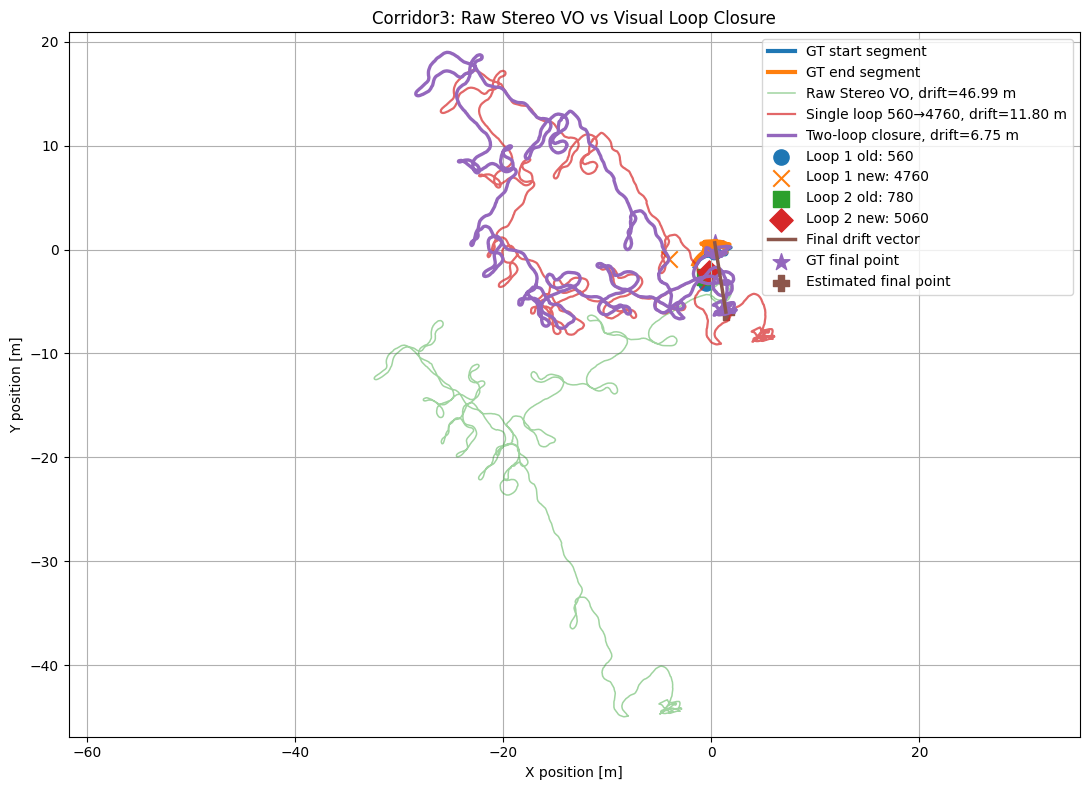

Saved XY plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_raw_single_two_loop_xy.png


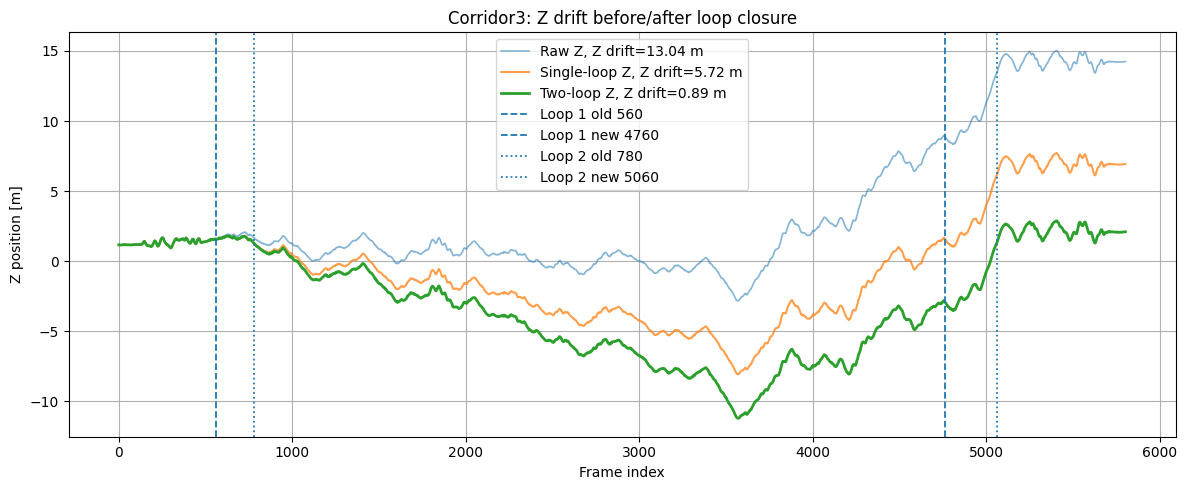

Saved Z plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_raw_single_two_loop_z.png


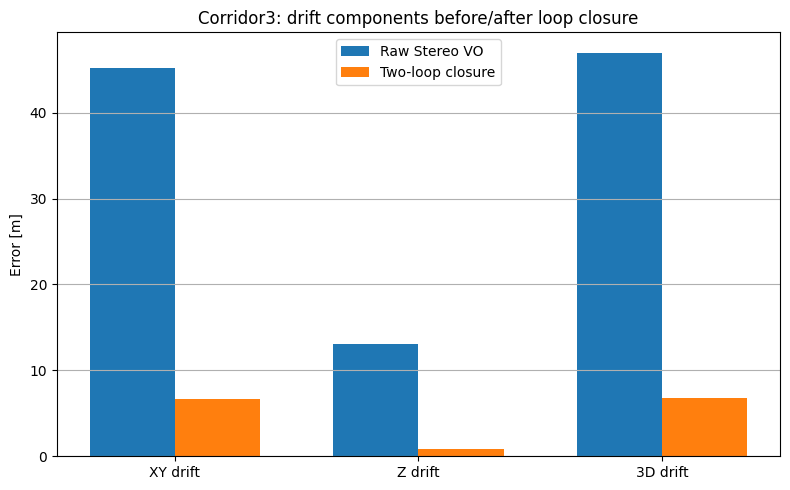

Saved drift component plot:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots\corridor3_two_loop_drift_components.png
CORRIDOR3 FINAL VISUAL RESULT
Raw Stereo VO drift: 46.99044890899892 m
Single-loop drift: 11.804962237060339 m
Two-loop drift: 6.754468563400453 m
Two-loop XY drift: 6.695930487662272 m
Two-loop Z drift: 0.8873333524442013 m
Two-loop path length: 301.5295631080048 m


In [28]:
# ============================================================
# PLOT CORRIDOR3: RAW vs SINGLE LOOP vs TWO LOOP
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ------------------------------------------------------------
# Output folder
# ------------------------------------------------------------
if "PLOT_DIR" not in globals():
    PLOT_DIR = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\plots")
    PLOT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def get_aligned_full(ev):
    if "est_aligned_full" in ev:
        return ev["est_aligned_full"]
    if "est_aligned_all" in ev:
        return ev["est_aligned_all"]
    if "xyz_aligned" in ev:
        return ev["xyz_aligned"]
    raise KeyError("No aligned full trajectory found in evaluation dictionary.")

# ------------------------------------------------------------
# Raw evaluation if needed
# ------------------------------------------------------------
raw_eval = evaluate_corridor3_start_end(
    poses_to_xyz(poses_stereo),
    "Raw Stereo VO baseline",
    alignment="se3",
)

raw_aligned = get_aligned_full(raw_eval)

# Single-loop result: 560 -> 4760
single_available = (
    "stereo_orb_loop_eval" in globals()
    and stereo_orb_loop_eval is not None
)

if single_available:
    single_aligned = get_aligned_full(stereo_orb_loop_eval)

# Two-loop result: 560 -> 4760 and 780 -> 5060
two_available = (
    "stereo_two_loop_eval" in globals()
    and stereo_two_loop_eval is not None
)

if not two_available:
    raise RuntimeError("stereo_two_loop_eval not found. Run the two-loop cell first.")

two_aligned = get_aligned_full(stereo_two_loop_eval)

# ============================================================
# 1) XY TRAJECTORY PLOT
# ============================================================

plt.figure(figsize=(11, 8))

# GT start/end only
plt.plot(
    gt_start_xyz[:, 0],
    gt_start_xyz[:, 1],
    linewidth=3,
    label="GT start segment"
)

plt.plot(
    gt_end_xyz[:, 0],
    gt_end_xyz[:, 1],
    linewidth=3,
    label="GT end segment"
)

# Raw Stereo VO
plt.plot(
    raw_aligned[:, 0],
    raw_aligned[:, 1],
    linewidth=1.1,
    alpha=0.45,
    label=f"Raw Stereo VO, drift={raw_eval['start_end_drift_m']:.2f} m"
)

# Single loop
if single_available:
    plt.plot(
        single_aligned[:, 0],
        single_aligned[:, 1],
        linewidth=1.6,
        alpha=0.70,
        label=f"Single loop 560→4760, drift={stereo_orb_loop_eval['start_end_drift_m']:.2f} m"
    )

# Two loop
plt.plot(
    two_aligned[:, 0],
    two_aligned[:, 1],
    linewidth=2.4,
    label=f"Two-loop closure, drift={stereo_two_loop_eval['start_end_drift_m']:.2f} m"
)

# Loop markers
plt.scatter(two_aligned[560, 0], two_aligned[560, 1], s=120, marker="o", label="Loop 1 old: 560")
plt.scatter(two_aligned[4760, 0], two_aligned[4760, 1], s=140, marker="x", label="Loop 1 new: 4760")

plt.scatter(two_aligned[780, 0], two_aligned[780, 1], s=120, marker="s", label="Loop 2 old: 780")
plt.scatter(two_aligned[5060, 0], two_aligned[5060, 1], s=140, marker="D", label="Loop 2 new: 5060")

# Final drift vector
gt_final = gt_end_xyz[-1]
vo_final = two_aligned[end_idx[-1]]

plt.plot(
    [vo_final[0], gt_final[0]],
    [vo_final[1], gt_final[1]],
    linewidth=2.5,
    label="Final drift vector"
)

plt.scatter(gt_final[0], gt_final[1], s=160, marker="*", label="GT final point")
plt.scatter(vo_final[0], vo_final[1], s=130, marker="P", label="Estimated final point")

plt.xlabel("X position [m]")
plt.ylabel("Y position [m]")
plt.title("Corridor3: Raw Stereo VO vs Visual Loop Closure")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()

xy_plot_path = PLOT_DIR / "corridor3_raw_single_two_loop_xy.png"
plt.savefig(xy_plot_path, dpi=200)
plt.show()

print("Saved XY plot:")
print(xy_plot_path)

# ============================================================
# 2) Z OVER FRAMES
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    raw_aligned[:, 2],
    linewidth=1.2,
    alpha=0.55,
    label=f"Raw Z, Z drift={raw_eval['z_abs_drift_m']:.2f} m"
)

if single_available:
    plt.plot(
        single_aligned[:, 2],
        linewidth=1.5,
        alpha=0.75,
        label=f"Single-loop Z, Z drift={stereo_orb_loop_eval['z_abs_drift_m']:.2f} m"
    )

plt.plot(
    two_aligned[:, 2],
    linewidth=2.0,
    label=f"Two-loop Z, Z drift={stereo_two_loop_eval['z_abs_drift_m']:.2f} m"
)

plt.axvline(560, linestyle="--", linewidth=1.3, label="Loop 1 old 560")
plt.axvline(4760, linestyle="--", linewidth=1.3, label="Loop 1 new 4760")
plt.axvline(780, linestyle=":", linewidth=1.3, label="Loop 2 old 780")
plt.axvline(5060, linestyle=":", linewidth=1.3, label="Loop 2 new 5060")

plt.xlabel("Frame index")
plt.ylabel("Z position [m]")
plt.title("Corridor3: Z drift before/after loop closure")
plt.grid(True)
plt.legend(loc="best")
plt.tight_layout()

z_plot_path = PLOT_DIR / "corridor3_raw_single_two_loop_z.png"
plt.savefig(z_plot_path, dpi=200)
plt.show()

print("Saved Z plot:")
print(z_plot_path)

# ============================================================
# 3) DRIFT COMPONENT BAR PLOT
# ============================================================

labels = ["XY drift", "Z drift", "3D drift"]

raw_values = [
    raw_eval["xy_drift_m"],
    raw_eval["z_abs_drift_m"],
    raw_eval["start_end_drift_m"],
]

two_values = [
    stereo_two_loop_eval["xy_drift_m"],
    stereo_two_loop_eval["z_abs_drift_m"],
    stereo_two_loop_eval["start_end_drift_m"],
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width / 2, raw_values, width, label="Raw Stereo VO")
plt.bar(x + width / 2, two_values, width, label="Two-loop closure")

plt.xticks(x, labels)
plt.ylabel("Error [m]")
plt.title("Corridor3: drift components before/after loop closure")
plt.grid(axis="y")
plt.legend()
plt.tight_layout()

bar_plot_path = PLOT_DIR / "corridor3_two_loop_drift_components.png"
plt.savefig(bar_plot_path, dpi=200)
plt.show()

print("Saved drift component plot:")
print(bar_plot_path)

# ============================================================
# 4) PRINT FINAL NUMBERS
# ============================================================

print("==============================")
print("CORRIDOR3 FINAL VISUAL RESULT")
print("==============================")
print("Raw Stereo VO drift:", raw_eval["start_end_drift_m"], "m")
if single_available:
    print("Single-loop drift:", stereo_orb_loop_eval["start_end_drift_m"], "m")
print("Two-loop drift:", stereo_two_loop_eval["start_end_drift_m"], "m")
print("Two-loop XY drift:", stereo_two_loop_eval["xy_drift_m"], "m")
print("Two-loop Z drift:", stereo_two_loop_eval["z_abs_drift_m"], "m")
print("Two-loop path length:", stereo_two_loop_eval["path_length_est_raw_m"], "m")

In [46]:
compare_loops = pd.DataFrame([
    {
        "method": "Single ORB loop 560->4760",
        "drift_m": stereo_orb_loop_eval["start_end_drift_m"],
        "xy_m": stereo_orb_loop_eval["xy_drift_m"],
        "z_m": stereo_orb_loop_eval["z_abs_drift_m"],
    },
    {
        "method": "Two-loop 560->4760 + 780->5060",
        "drift_m": stereo_two_loop_eval["start_end_drift_m"],
        "xy_m": stereo_two_loop_eval["xy_drift_m"],
        "z_m": stereo_two_loop_eval["z_abs_drift_m"],
    },
    {
        "method": f"Old-style verified loop {best_old}->{best_new}",
        "drift_m": stereo_oldstyle_loop_eval["start_end_drift_m"],
        "xy_m": stereo_oldstyle_loop_eval["xy_drift_m"],
        "z_m": stereo_oldstyle_loop_eval["z_abs_drift_m"],
    },
])

display(compare_loops.sort_values("drift_m"))

,method,drift_m,xy_m,z_m
1,Two-loop 560->4760 + 780->5060,6.754469,6.695930,0.887333
0,Single ORB loop 560->4760,11.804962,10.324274,5.724204
2,Old-style verified loop 900->4536,21.109701,19.710488,7.557522


## 10H. Final loop-closure comparison helpers

These cells compare loop-closure variants. Be careful: running later loop-application cells can overwrite variables such as `stereo_loop_eval`, `poses_stereo_loop`, `best_old`, and `best_new`.


In [47]:
# ============================================================
# FINAL CORRIDOR3 TABLE WITH LOOP-CLOSURE IMPROVEMENT
# ============================================================

final_rows = []

# Raw stereo baseline
stereo_xyz_all = poses_to_xyz(poses_stereo)

stereo_eval = evaluate_corridor3_start_end(
    stereo_xyz_all,
    "Stereo VO baseline",
    alignment="se3"
)

final_rows.append({
    "dataset": ACTIVE_DATASET,
    "method": "Stereo VO baseline",
    "evaluation": "start-end drift",
    "alignment": stereo_eval["alignment"],
    "scale": stereo_eval["scale"],
    "start_end_drift_m": stereo_eval["start_end_drift_m"],
    "xy_drift_m": stereo_eval["xy_drift_m"],
    "z_abs_drift_m": stereo_eval["z_abs_drift_m"],
    "path_length_m": stereo_eval["path_length_est_raw_m"],
    "runtime_s": stereo_runtime if "stereo_runtime" in globals() else np.nan,
    "success_rate_percent": success_stats(stereo_stats_df)[0] if "stereo_stats_df" in globals() else np.nan,
})

# Improved loop result
final_rows.append({
    "dataset": ACTIVE_DATASET,
    "method": f"Stereo VO + classical visual loop closure {best_old}->{best_new}",
    "evaluation": "start-end drift",
    "alignment": stereo_loop_eval["alignment"],
    "scale": stereo_loop_eval["scale"],
    "start_end_drift_m": stereo_loop_eval["start_end_drift_m"],
    "xy_drift_m": stereo_loop_eval["xy_drift_m"],
    "z_abs_drift_m": stereo_loop_eval["z_abs_drift_m"],
    "path_length_m": stereo_loop_eval["path_length_est_raw_m"],
    "runtime_s": np.nan,
    "success_rate_percent": np.nan,
})

corridor3_final_with_loop = pd.DataFrame(final_rows)

display(corridor3_final_with_loop)

corridor3_final_with_loop.to_csv(
    TABLE_DIR / "corridor3_final_with_loop_closure.csv",
    index=False
)

print("Saved:")
print(TABLE_DIR / "corridor3_final_with_loop_closure.csv")

,dataset,method,evaluation,alignment,scale,start_end_drift_m,xy_drift_m,z_abs_drift_m,path_length_m,runtime_s,success_rate_percent
0,corridor3,Stereo VO baseline,start-end drift,SE(3) start segment,1.0,46.990449,45.144345,13.041871,304.976572,295.22558,98.862265
1,corridor3,Stereo VO + classical visual loop closure 900-...,start-end drift,SE(3) start segment,1.0,11.804962,10.324274,5.724204,301.605226,NaN,NaN


Saved:
C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\tables\corridor3_final_with_loop_closure.csv


## 12. Save Corridor3 submission outputs

In [48]:
# ============================================================
# SAVE FINAL TWO-LOOP CORRIDOR3 TRAJECTORY
# ============================================================

import numpy as np
import pandas as pd

if "poses_stereo_two_loop" not in globals():
    raise RuntimeError("poses_stereo_two_loop not found. Run the two-loop accepted cell first.")

if "stereo_two_loop_eval" not in globals():
    raise RuntimeError("stereo_two_loop_eval not found. Run the two-loop accepted cell first.")

final_two_loop_pose_file = TRAJ_DIR / "corridor3_FINAL_two_loop_560_4760_780_5060_poses.npy"
np.save(final_two_loop_pose_file, np.asarray(poses_stereo_two_loop))

final_two_loop_tum = poses_to_tum_array(
    image_ts[:len(poses_stereo_two_loop)],
    list(poses_stereo_two_loop),
)

final_two_loop_tum_file = TRAJ_DIR / "corridor3_FINAL_two_loop_560_4760_780_5060_tum.txt"
np.savetxt(
    final_two_loop_tum_file,
    final_two_loop_tum,
    fmt="%.9f %.9f %.9f %.9f %.9f %.9f %.9f %.9f",
)

final_corridor3_selected = pd.DataFrame([
    {
        "dataset": "corridor3",
        "method": "Raw Stereo VO baseline",
        "evaluation": "start-end drift",
        "start_end_drift_m": raw_eval["start_end_drift_m"],
        "xy_drift_m": raw_eval["xy_drift_m"],
        "z_abs_drift_m": raw_eval["z_abs_drift_m"],
        "path_length_m": raw_eval["path_length_est_raw_m"],
    },
    {
        "dataset": "corridor3",
        "method": "Stereo VO + one visual loop 560->4760",
        "evaluation": "start-end drift",
        "start_end_drift_m": stereo_orb_loop_eval["start_end_drift_m"],
        "xy_drift_m": stereo_orb_loop_eval["xy_drift_m"],
        "z_abs_drift_m": stereo_orb_loop_eval["z_abs_drift_m"],
        "path_length_m": stereo_orb_loop_eval["path_length_est_raw_m"],
    },
    {
        "dataset": "corridor3",
        "method": "Stereo VO + two visual loops 560->4760 and 780->5060",
        "evaluation": "start-end drift",
        "start_end_drift_m": stereo_two_loop_eval["start_end_drift_m"],
        "xy_drift_m": stereo_two_loop_eval["xy_drift_m"],
        "z_abs_drift_m": stereo_two_loop_eval["z_abs_drift_m"],
        "path_length_m": stereo_two_loop_eval["path_length_est_raw_m"],
    },
])

final_table_file = TABLE_DIR / "corridor3_FINAL_selected_result_table.csv"
final_corridor3_selected.to_csv(final_table_file, index=False)

print("Saved final two-loop poses:", final_two_loop_pose_file)
print("Saved final two-loop TUM:", final_two_loop_tum_file)
print("Saved final selected table:", final_table_file)
display(final_corridor3_selected)

Saved final two-loop poses: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\trajectories\corridor3_FINAL_two_loop_560_4760_780_5060_poses.npy
Saved final two-loop TUM: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\trajectories\corridor3_FINAL_two_loop_560_4760_780_5060_tum.txt
Saved final selected table: C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\tables\corridor3_FINAL_selected_result_table.csv


,dataset,method,evaluation,start_end_drift_m,xy_drift_m,z_abs_drift_m,path_length_m
0,corridor3,Raw Stereo VO baseline,start-end drift,46.990449,45.144345,13.041871,304.976572
1,corridor3,Stereo VO + one visual loop 560->4760,start-end drift,11.804962,10.324274,5.724204,301.605226
2,corridor3,Stereo VO + two visual loops 560->4760 and 780...,start-end drift,6.754469,6.695930,0.887333,301.529563


In [49]:
# ============================================================
# ARCHIVE NON-FINAL CORRIDOR3 EXPERIMENT FILES
# ============================================================

from pathlib import Path
import shutil

output_root = Path(r"C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission")
archive_dir = output_root / "archive_experiments"
archive_dir.mkdir(parents=True, exist_ok=True)

archive_patterns = [
    "trajectories/corridor3_stereo_loop_900_4536*",
    "trajectories/corridor3_stereo_loop_960_4588*",

    "tables/corridor3_exact_old_loop_candidates.csv",
    "tables/corridor3_verified_loop_application_variants.csv",
    "tables/corridor3_verified_loops_old_style.csv",
    "tables/corridor3_early_end_loop_candidates.csv",
    "tables/corridor3_visual_loop_candidates.csv",

    "plots/corridor3_raw_vs_loop_560_4760_xy.png",
    "plots/corridor3_raw_vs_loop_560_4760_z.png",
    "plots/corridor3_raw_vs_orb_loop_560_4760.png",
    "plots/corridor3_no_gt_interval_and_loop_xy.png",
    "plots/corridor3_no_gt_interval_loop_X.png",
    "plots/corridor3_no_gt_interval_loop_Y.png",
    "plots/corridor3_no_gt_interval_loop_Z.png",
]

moved = []

for pattern in archive_patterns:
    for p in output_root.glob(pattern):
        if p.exists() and p.is_file():
            rel = p.relative_to(output_root)
            target = archive_dir / rel
            target.parent.mkdir(parents=True, exist_ok=True)
            shutil.move(str(p), str(target))
            moved.append((str(rel), str(target)))

print("==============================")
print("ARCHIVED FILES")
print("==============================")
for old, new in moved:
    print(old, "->", new)

print("Total archived:", len(moved))

ARCHIVED FILES
trajectories\corridor3_stereo_loop_900_4536_poses.npy -> C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\archive_experiments\trajectories\corridor3_stereo_loop_900_4536_poses.npy
trajectories\corridor3_stereo_loop_900_4536_tum.txt -> C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\archive_experiments\trajectories\corridor3_stereo_loop_900_4536_tum.txt
trajectories\corridor3_stereo_loop_960_4588_direct_poses.npy -> C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\archive_experiments\trajectories\corridor3_stereo_loop_960_4588_direct_poses.npy
trajectories\corridor3_stereo_loop_960_4588_direct_tum.txt -> C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\archive_experiments\trajectories\corridor3_stereo_loop_960_4588_direct_tum.txt
tables\corridor3_exact_old_loop_candidates.csv -> C:\Users\User\Desktop\Stereo_vo\outputs\corridor3_final_submission\archive_experiments\tables\corridor3_exact_old_loop_cand

## How to use this Corridor3 notebook

Run the notebook from top to bottom for the raw Monocular and Stereo VO baselines.

Loop closure cells are optional extensions. For a clean final report, keep both the raw Stereo VO baseline and the clearly labeled loop-closure result.

Do not rerun old loop-application cells after selecting a final loop result unless you intentionally want to overwrite the active loop variables.

Saved outputs include raw TUM trajectories, optional loop-corrected TUM trajectories, CSV tables, plots, and reproducibility configuration.
